In [ ]:
import statistics
import numpy as np
import pandas as pd



# Plot
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import seaborn as sns

from sklearn import tree
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier , RandomForestClassifier ,AdaBoostClassifier ,GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score, auc

In [ ]:
park_234733T = pd.read_csv('parkinson_disease_assignment - Copy.csv')
park_234733T.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE,DCAT
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,N
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,L
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,M
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,M
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,L


In [ ]:
park_234733T

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE,DCAT
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,N
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,L
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,M
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,M
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050,L
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895,L
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728,J
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306,L


Parkinson disease (PD) is a brain condition that causes problems with movement, mental health, sleep, pain and other health issues.

MDVP:Fo(Hz) - Average vocal fundamental frequency
MDVP:Fhi(Hz) - Maximum vocal fundamental frequency
MDVP:Flo(Hz) - Minimum vocal fundamental frequency * MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP - Several measures of variation in fundamental frequency
MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA - Several measures of variation in amplitude
NHR,HNR - Two measures of ratio of noise to tonal components in the voice
status - Health status of the subject (one) - Parkinson's, (zero) - healthy
RPDE,D2 - Two nonlinear dynamical complexity measures
DFA - Signal fractal scaling exponent * spread1,spread2,PPE - Three nonlinear measures of fundamental frequency variation

## **DATA Preparation**


In [ ]:
park_234733T.shape


(195, 25)

In [ ]:
park_234733T.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      194 non-null    float64
 3   MDVP:Flo(Hz)      194 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          194 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      194 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       194 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [ ]:
park_234733T.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,194.000000,194.000000,195.000000,195.000000,194.000000,195.000000,195.000000,194.000000,195.000000,...,194.000000,195.000000,195.000000,195.000000,193.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,196.964072,116.337711,0.006220,0.000044,0.003318,0.003446,0.009920,0.029620,0.282251,...,0.047085,0.024847,21.885974,0.753846,0.499166,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.707069,43.633633,0.004848,0.000035,0.002971,0.002759,0.008903,0.018864,0.194877,...,0.030511,0.040418,4.425764,0.431878,0.104270,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.759250,84.181500,0.003460,0.000020,0.001665,0.001860,0.004985,0.016473,0.148500,...,0.024668,0.005925,19.198000,1.000000,0.422229,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,174.402000,104.205000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022965,0.221000,...,0.038435,0.011660,22.085000,1.000000,0.497480,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,223.311500,140.532750,0.007365,0.000060,0.003853,0.003955,0.011505,0.037650,0.350000,...,0.060883,0.025640,25.075500,1.000000,0.589956,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [ ]:
park_234733T.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),1
MDVP:Flo(Hz),1
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,1
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,1


In [ ]:
dup_parks_234733T=park_234733T.duplicated().sum()
print(dup_parks_234733T)

0


In [ ]:
park_234733T.status.unique()

array([1, 0])

In [ ]:
# There is 147 people affected
park_234733T.status.value_counts()

,count
status,
1,147
0,48


In [ ]:
last_column = park_234733T.pop('status')
park_234733T.insert(len(park_234733T.columns), 'status', last_column)

park_234733T.head()


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,DCAT,status
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,N,1
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,L,1
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,M,1
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,M,1
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,L,1


In [ ]:
#remove features that we are not in used
park_234733T = park_234733T.drop(['name','DCAT'], axis=1)
park_234733T.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,1
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,1
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,1
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,1
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,1


In [ ]:
n_park_234733T = park_234733T.copy()
n_park_234733T.dropna(inplace=True)
n_park_234733T.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,1
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,1
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,1
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,1
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,1


In [ ]:
#new data
n_park_234733T.shape

(190, 23)

In [ ]:
#old data
park_234733T.shape

(195, 23)

In [ ]:
NA_park_234733T = len(park_234733T) - len(n_park_234733T)
total_park_234733T = len(park_234733T)
perc_park_234733T = NA_park_234733T / total_park_234733T * 100
print(f'The percentage of null/NA for park is: {perc_park_234733T:.3g}%')


The percentage of null/NA for park is: 2.56%


In [ ]:
n_park_234733T.status.value_counts()

,count
status,
1,144
0,46


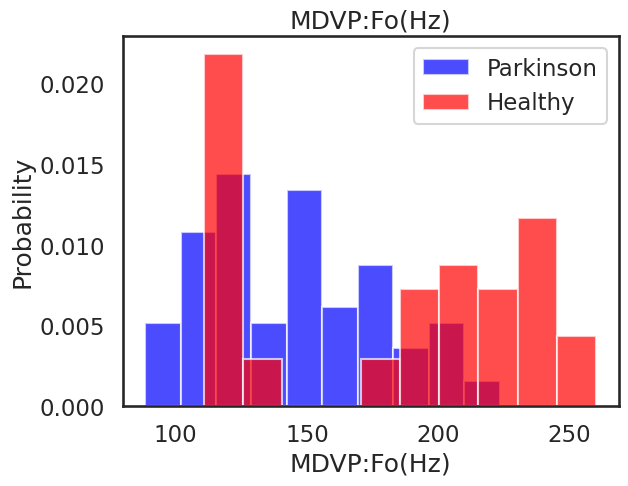

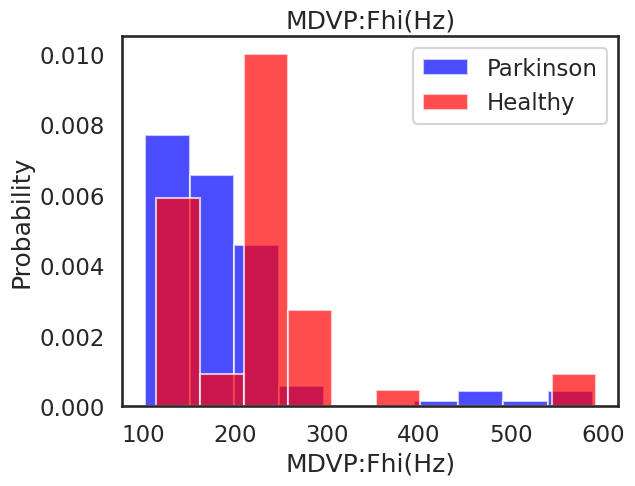

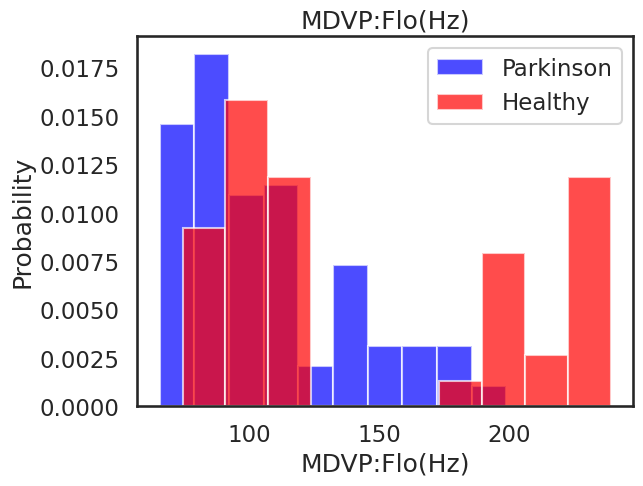

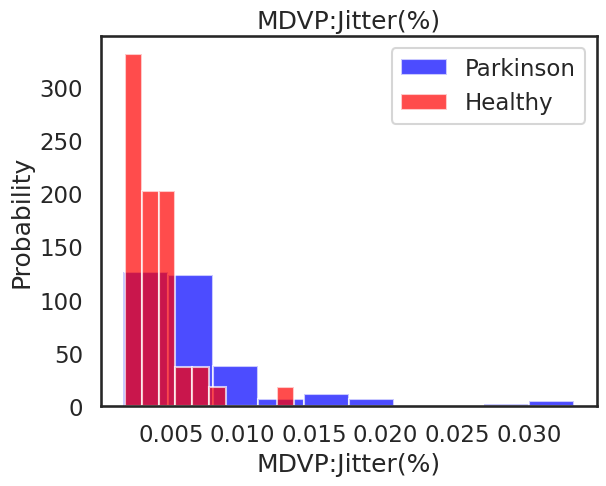

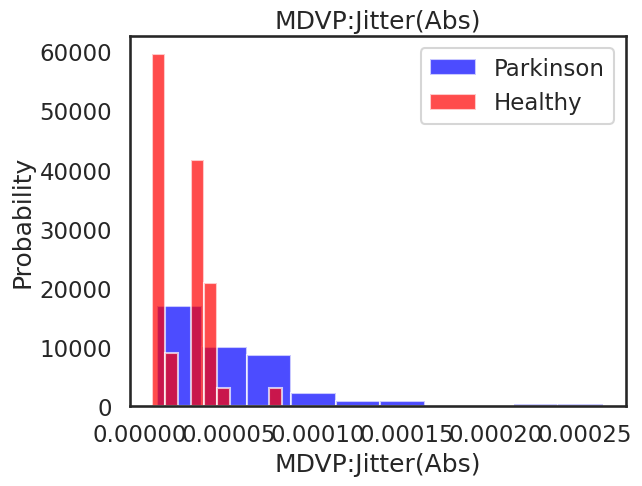

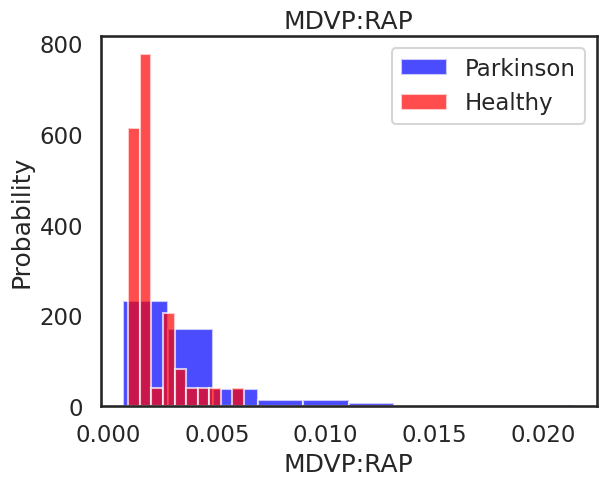

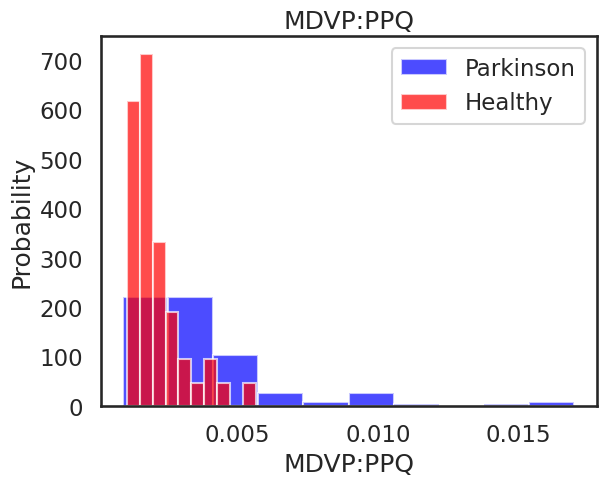

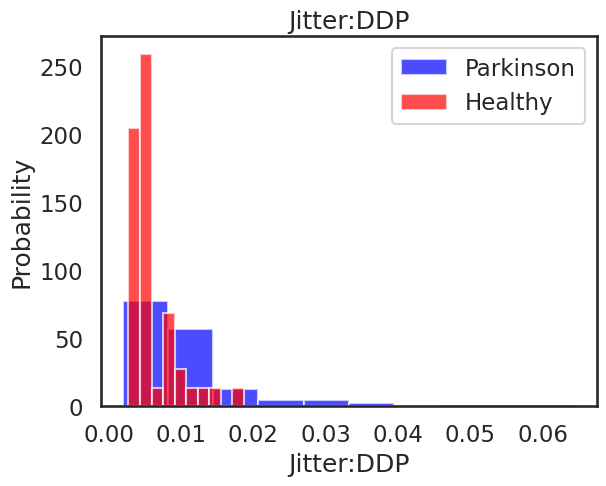

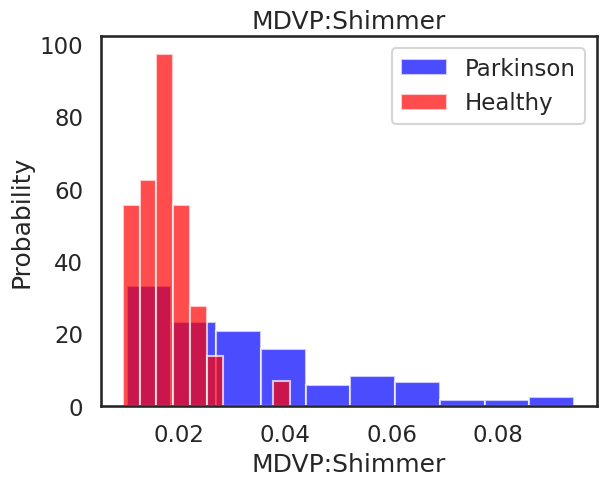

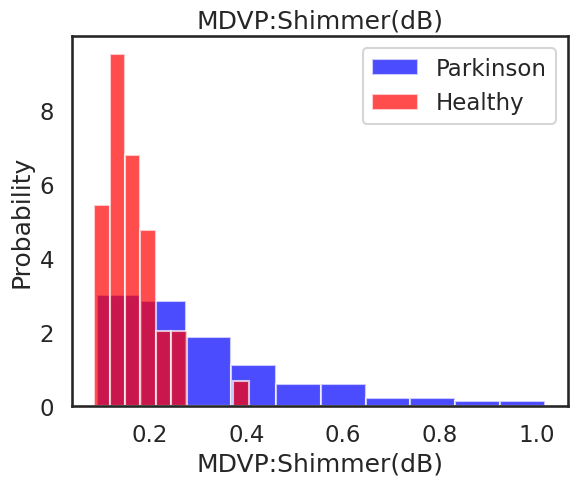

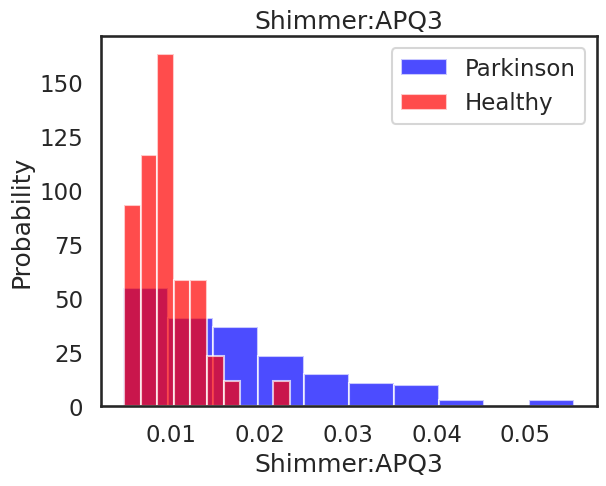

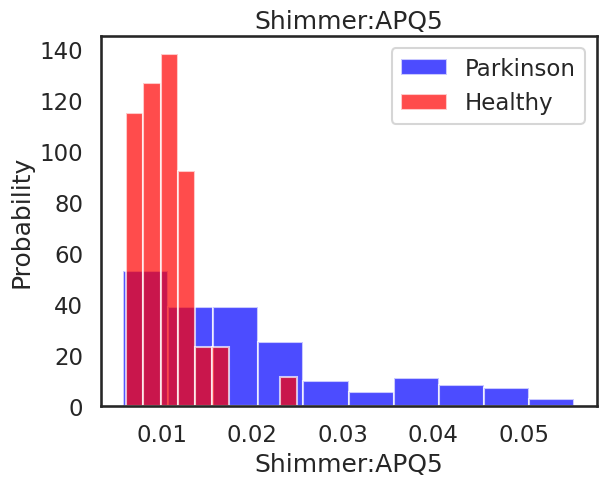

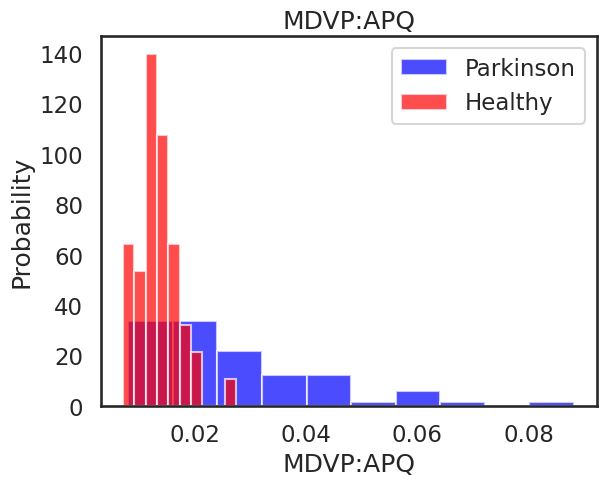

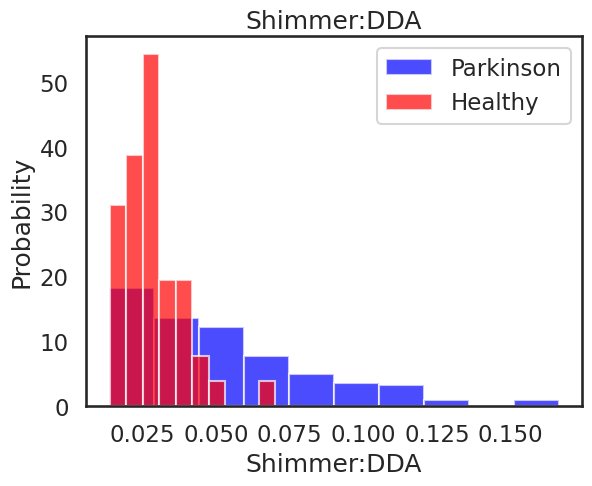

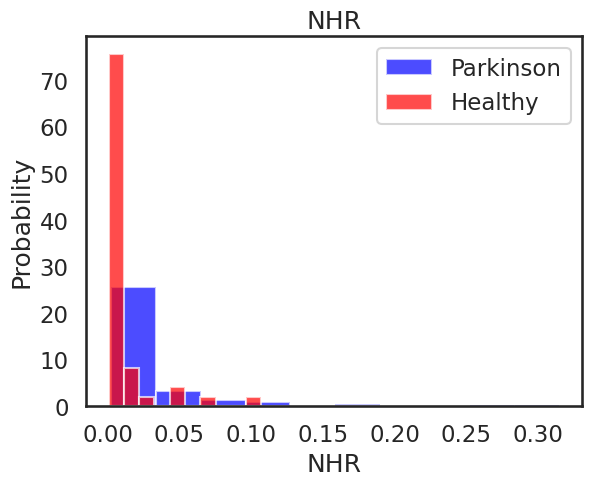

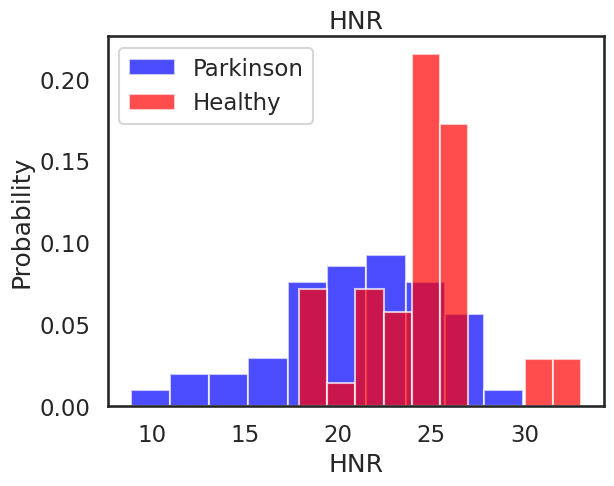

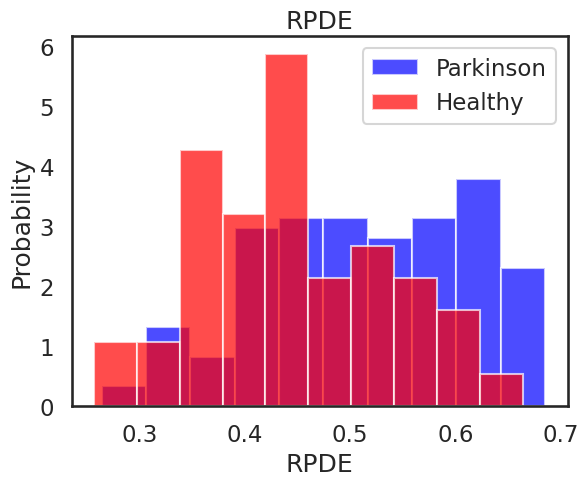

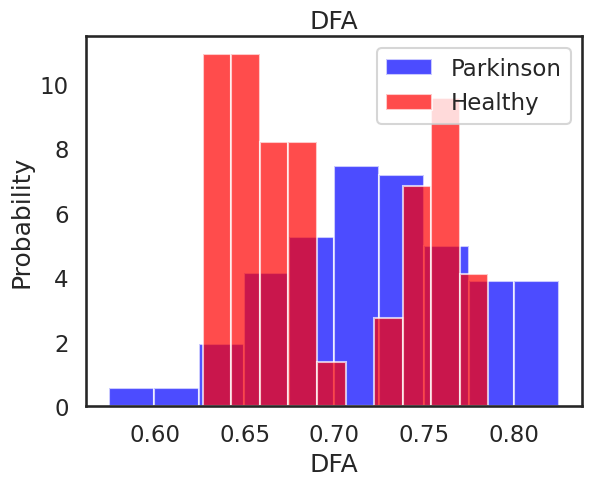

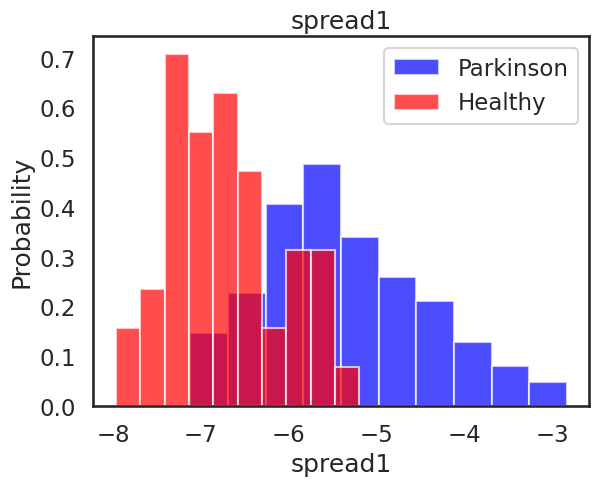

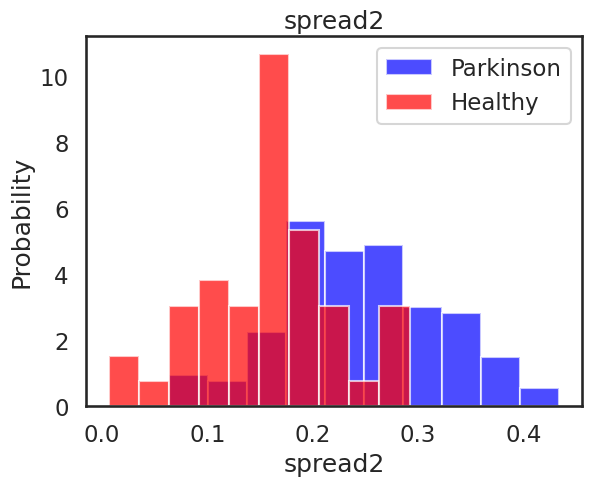

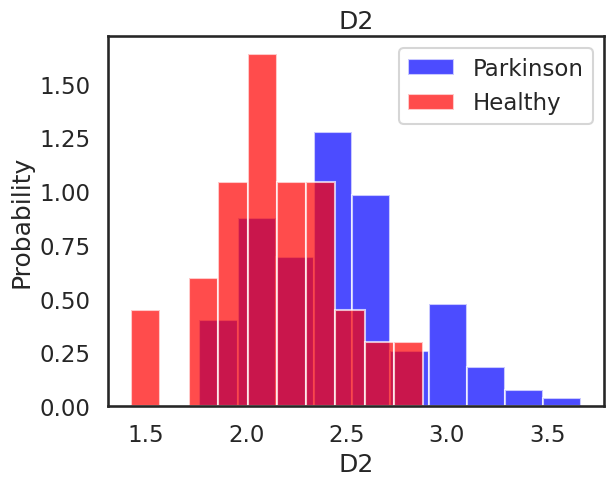

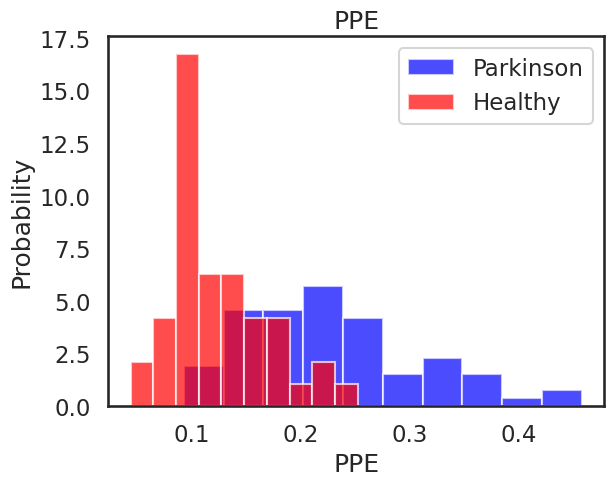

In [ ]:
for label in n_park_234733T.columns[:-1]:
    plt.hist(n_park_234733T[n_park_234733T["status"] == 1][label], color='blue', alpha=0.7, label='Parkinson', density=True)
    plt.hist(n_park_234733T[n_park_234733T["status"] == 0][label], color='red', alpha=0.7, label='Healthy', density=True)
    plt.title(label)
    plt.xlabel(label)
    plt.ylabel('Probability')
    plt.legend()
    plt.show()

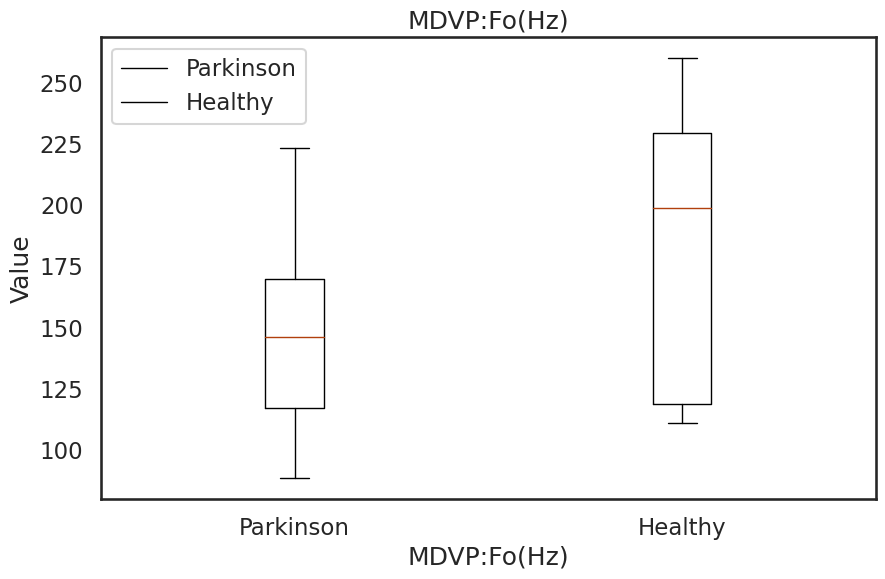

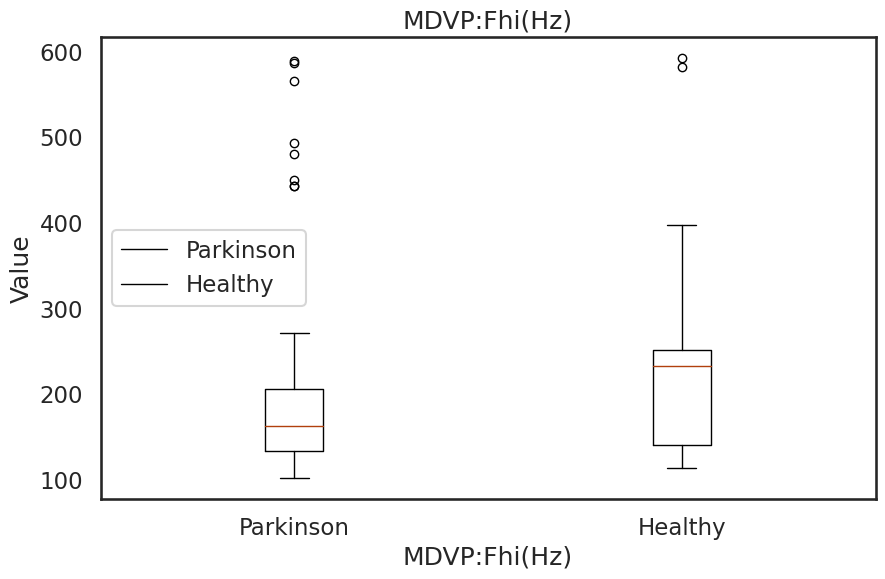

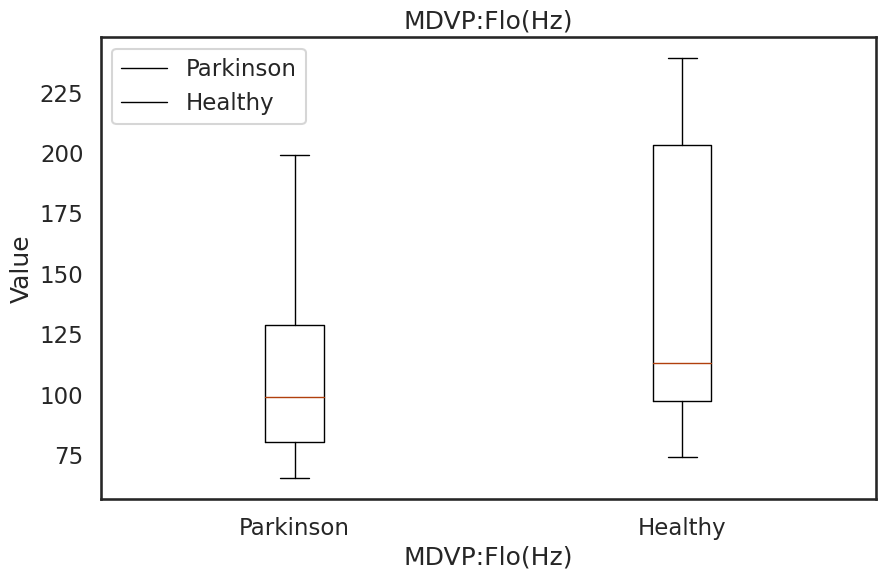

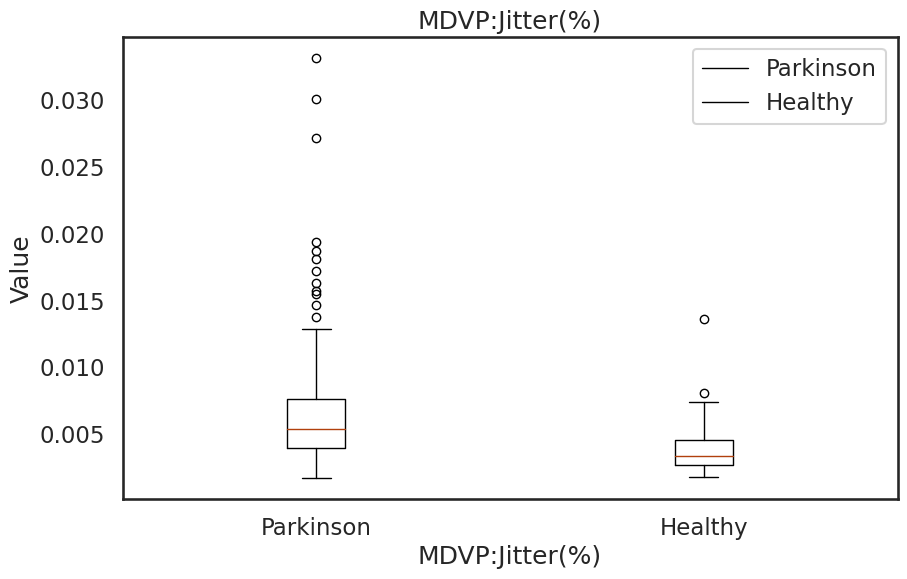

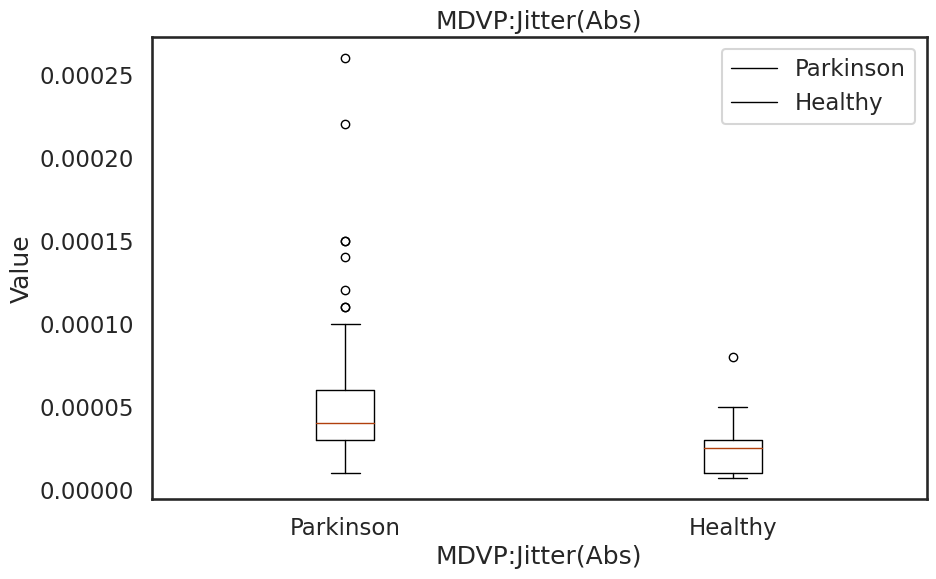

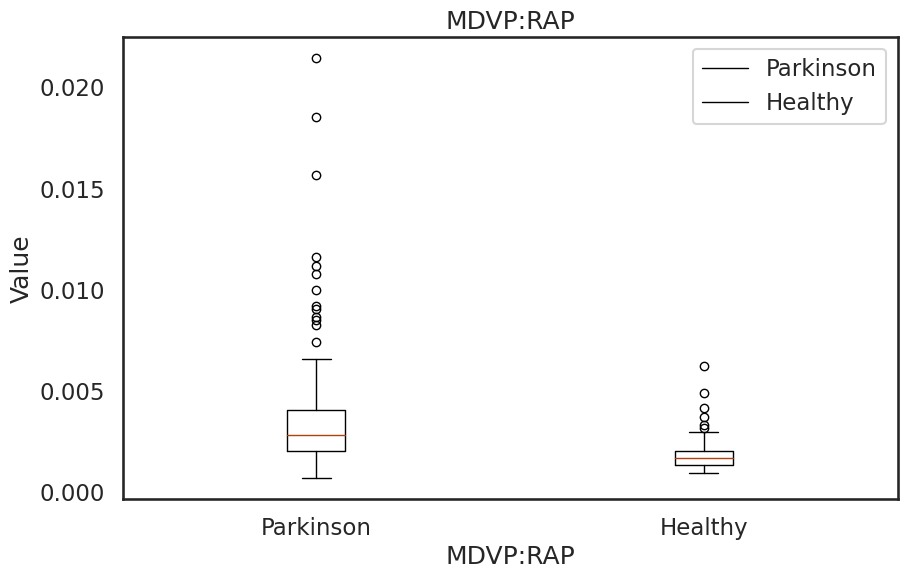

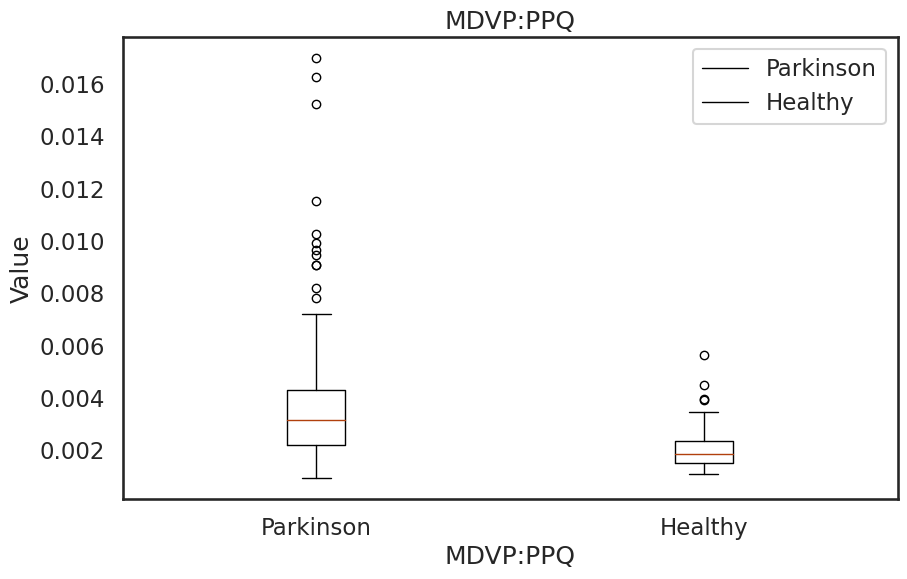

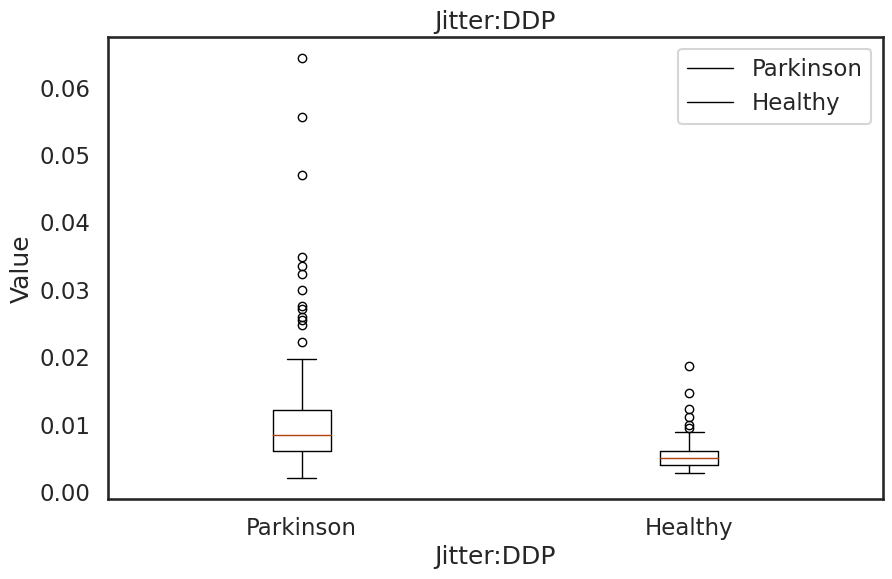

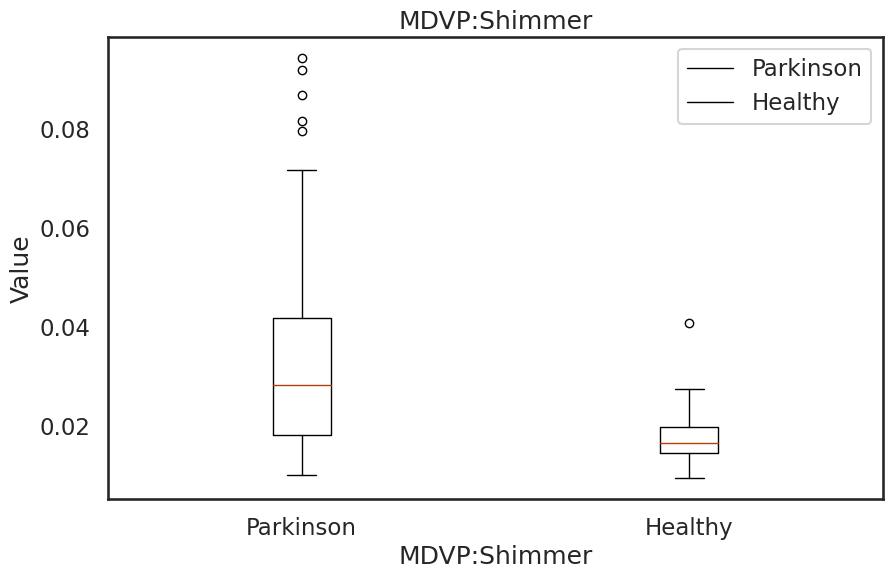

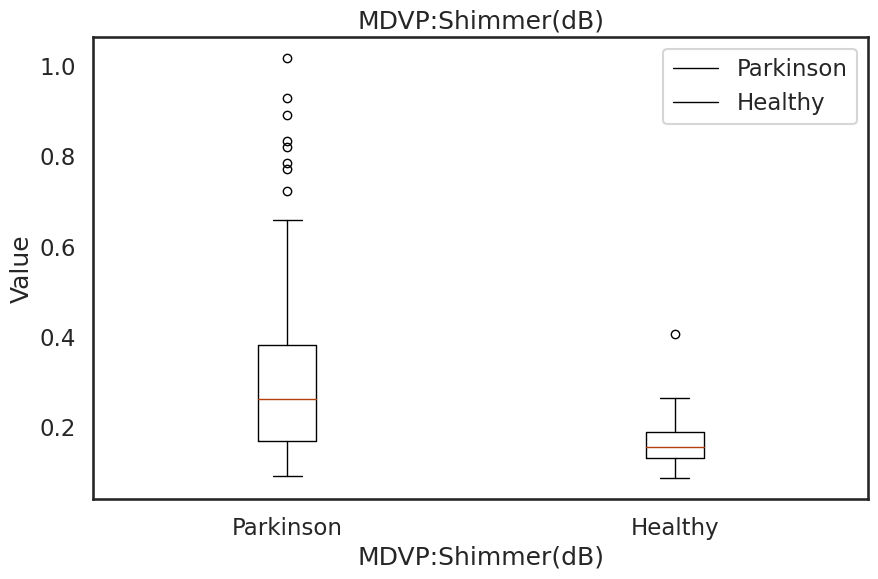

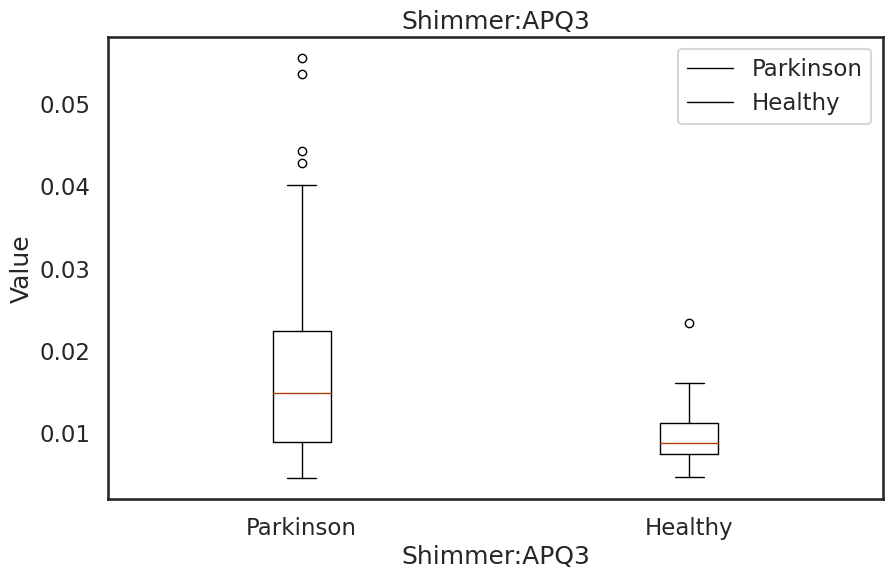

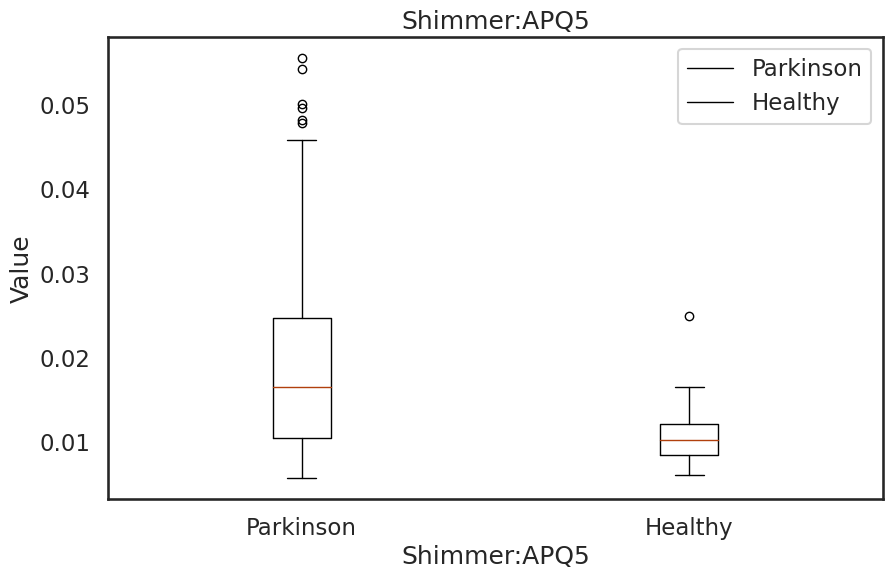

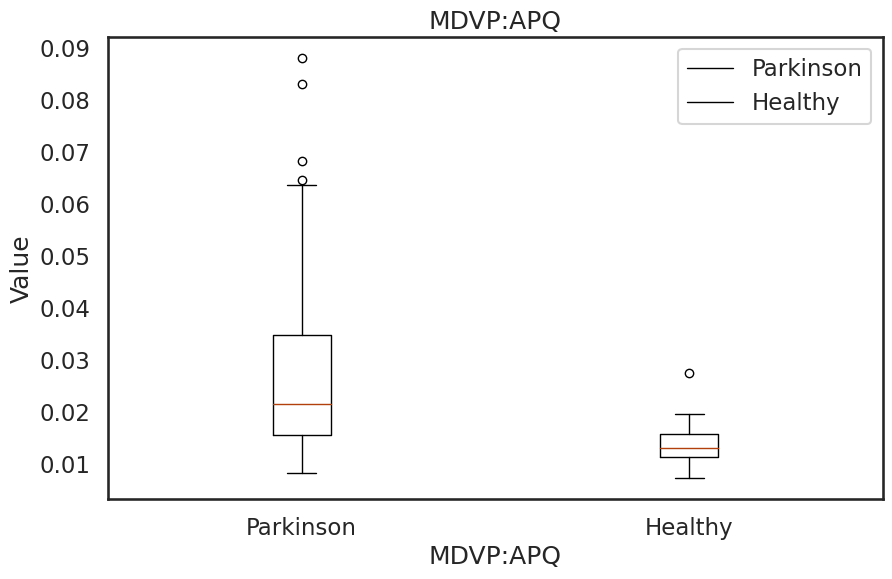

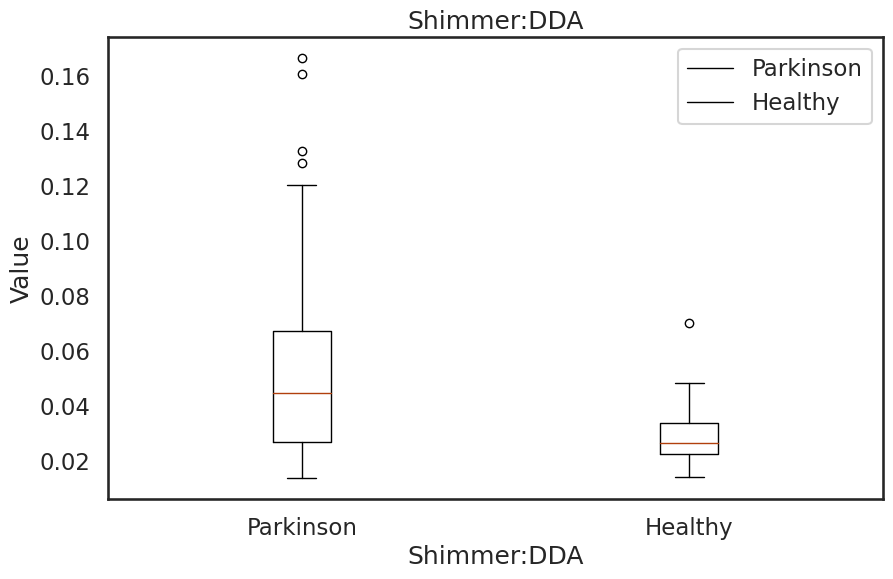

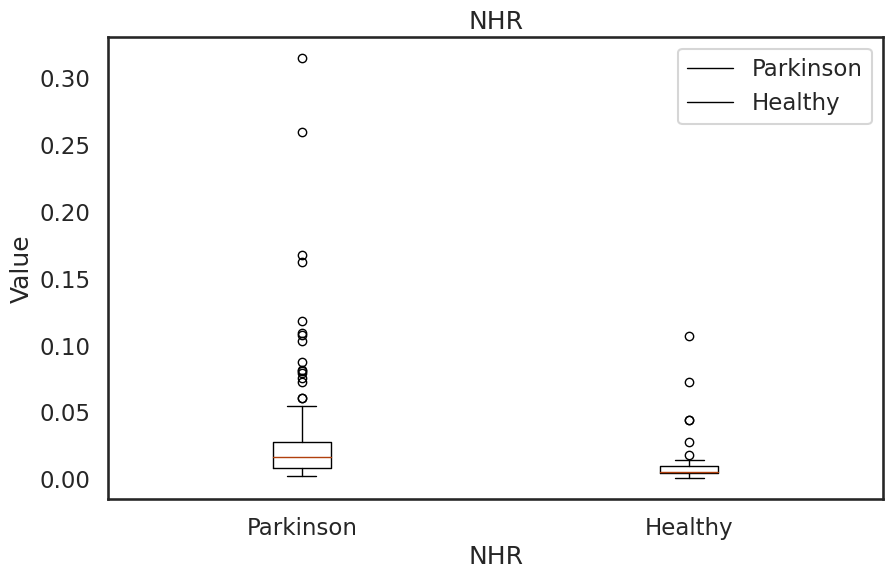

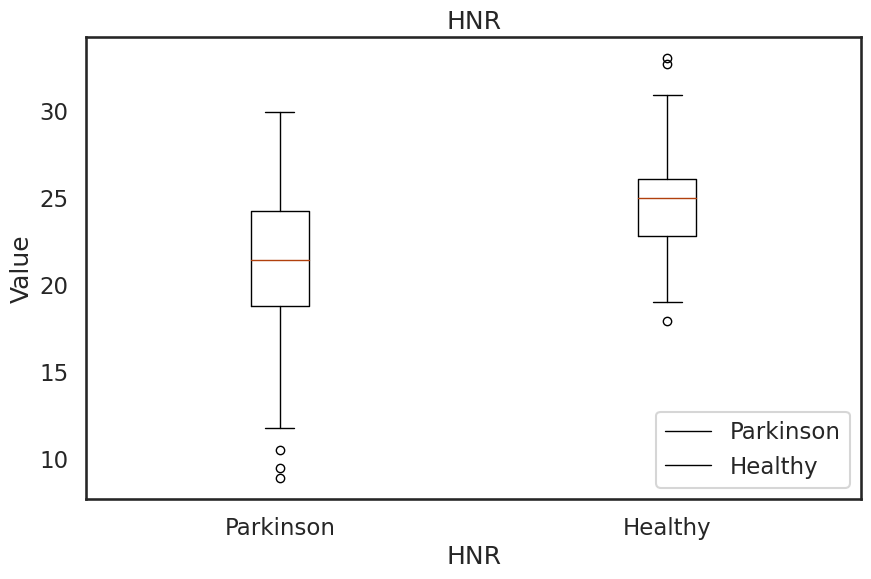

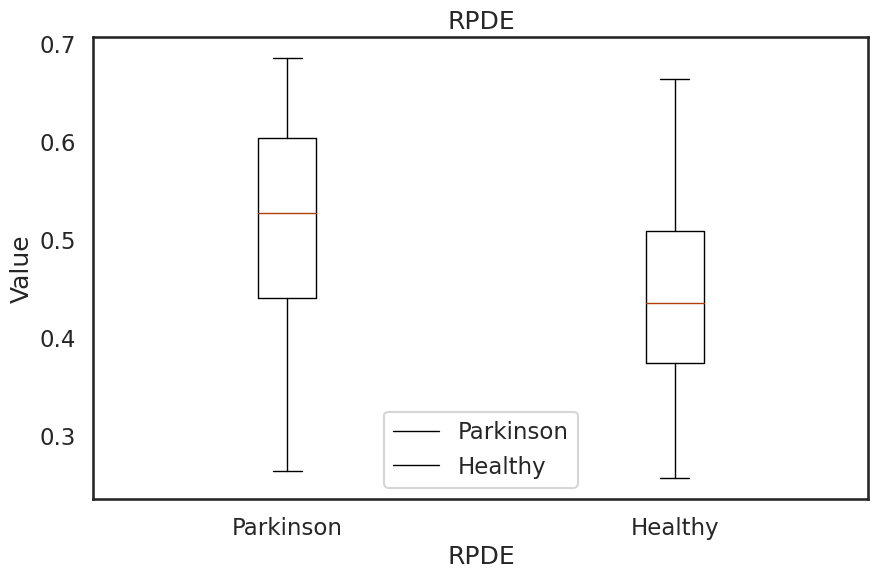

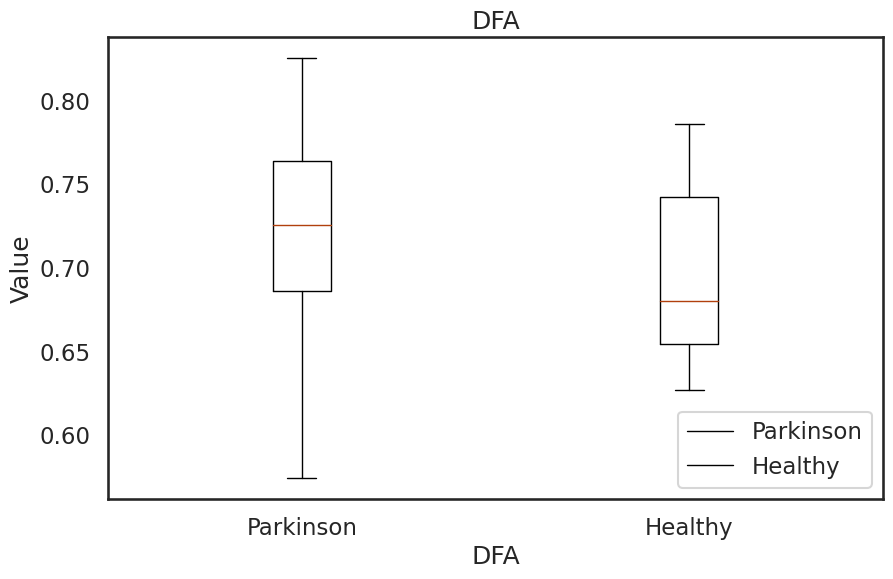

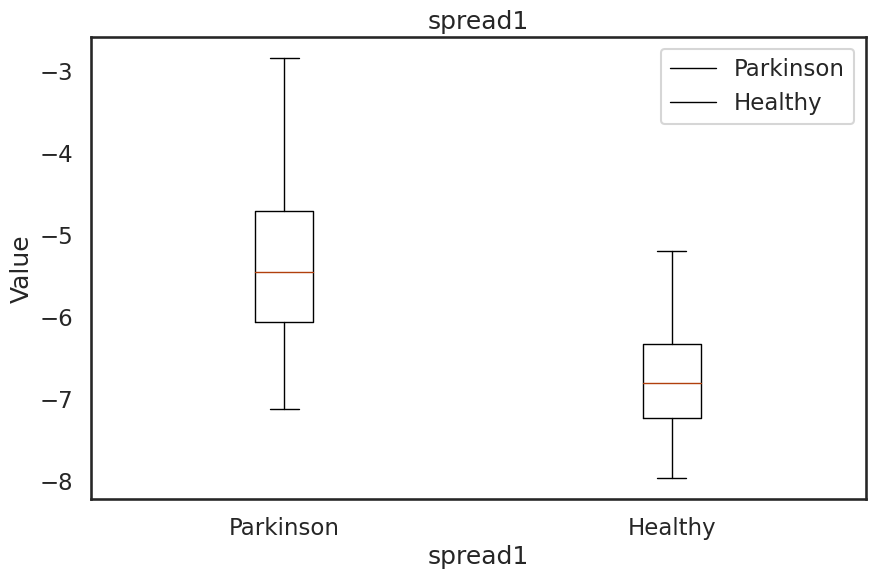

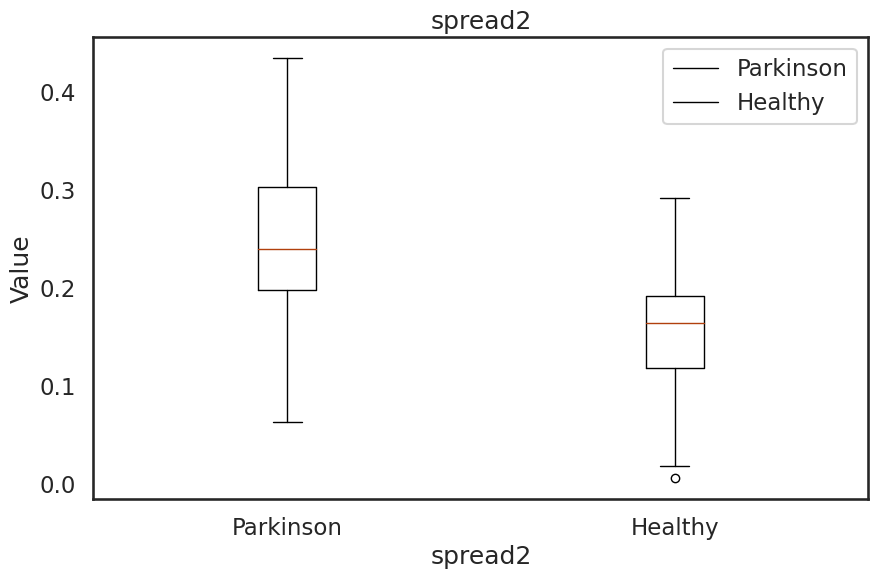

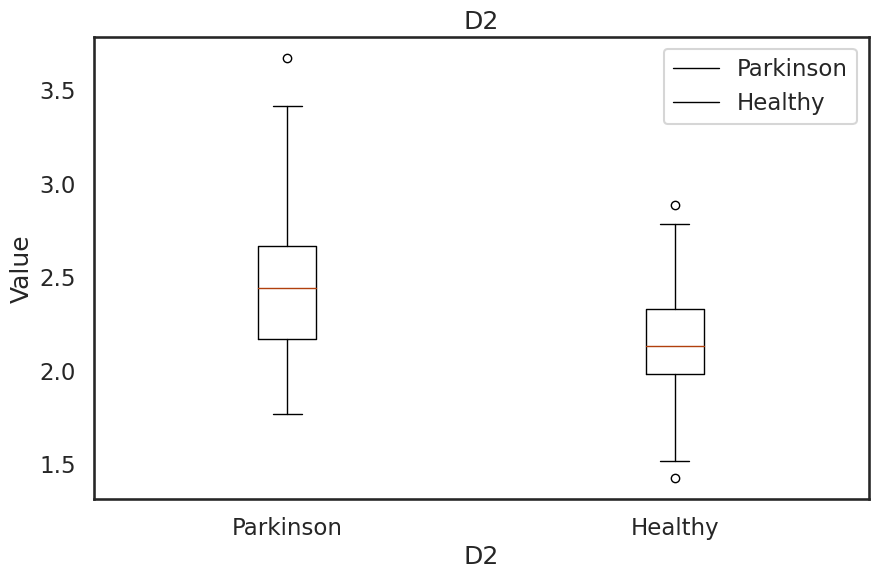

In [ ]:
for label in n_park_234733T.columns[:-2]:
    plt.figure(figsize=(10, 6))
    box = plt.boxplot([n_park_234733T[n_park_234733T["status"] == 1][label], n_park_234733T[n_park_234733T["status"] == 0][label]],
                      labels=['Parkinson', 'Healthy'])
    plt.title(label)
    plt.xlabel(label)
    plt.ylabel('Value')
    # Create custom legend
    plt.legend([box["boxes"][0], box["boxes"][1]], ['Parkinson', 'Healthy'])
    plt.show()

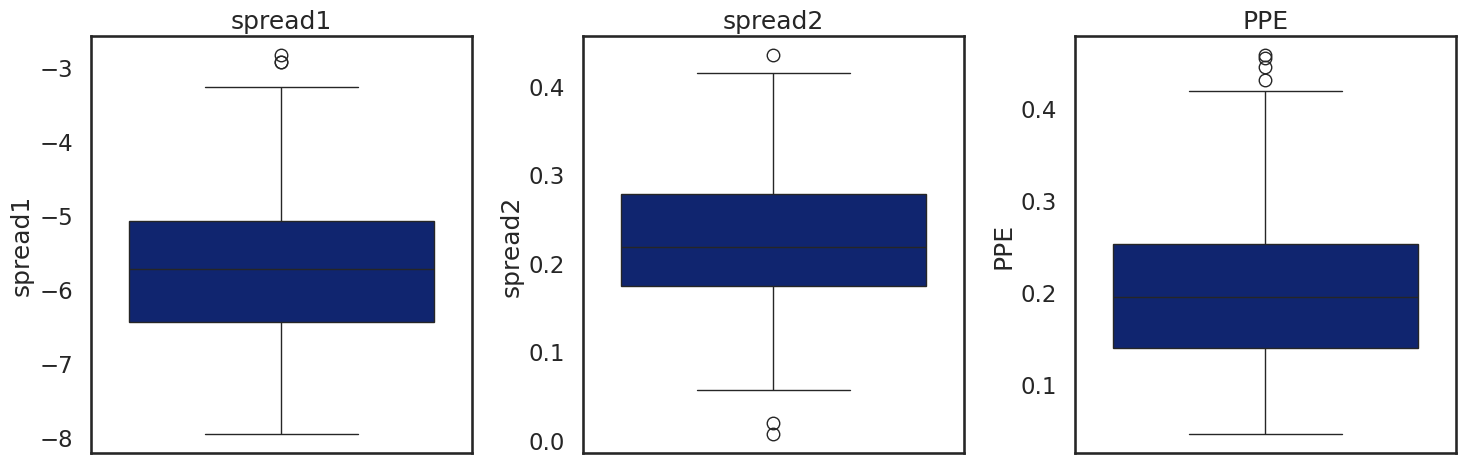

In [ ]:
columns_to_plot = ['spread1', 'spread2', 'PPE']

# Create a figure with subplots
plt.figure(figsize=(15, 5))

for index, column in enumerate(columns_to_plot, 1):
    plt.subplot(1, len(columns_to_plot), index)
    sns.boxplot(y=n_park_234733T[column])
    plt.title(column)  # Provides a title for each subplot

plt.tight_layout()  # Adjusts the plots to ensure they don't overlap
plt.show()  # Displays the plot

In [ ]:
cause_cols = [x for x in n_park_234733T.columns if x != 'status']
cause_cols

['MDVP:Fo(Hz)',
 'MDVP:Fhi(Hz)',
 'MDVP:Flo(Hz)',
 'MDVP:Jitter(%)',
 'MDVP:Jitter(Abs)',
 'MDVP:RAP',
 'MDVP:PPQ',
 'Jitter:DDP',
 'MDVP:Shimmer',
 'MDVP:Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'MDVP:APQ',
 'Shimmer:DDA',
 'NHR',
 'HNR',
 'RPDE',
 'DFA',
 'spread1',
 'spread2',
 'D2',
 'PPE']

## **DATA training**


In [ ]:
x = n_park_234733T[n_park_234733T.columns[:-1]]
y = n_park_234733T['status']


In [ ]:
n_park_234733T.shape

(190, 23)

In [ ]:
x.shape

(190, 22)

In [ ]:
y.shape

(190,)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(133, 22)
(57, 22)
(133,)
(57,)


## **Decision Tree**

I focused on making the Decision Tree model easy to understand, while handling non-linear patterns in the data. To avoid overfitting, we carefully selected the tree depth, knowing that deeper trees might capture too much noise. We used GridSearchCV to optimize key parameters like max_depth, max_features, min_samples_split, min_samples_leaf, and criterion. These adjustments helped prevent overfitting and improved overall performance. However, this conservative tuning led to a lower ROC AUC, meaning the model didn't balance sensitivity and specificity as well as before. While accuracy was higher, the model showed some bias. Our main concerns included the model's sensitivity to noisy data and its tendency to become biased with imbalanced datasets.

In [ ]:
TD_clf_234733T = tree.DecisionTreeClassifier(random_state=42)
TD_clf_234733T.fit(x_train, y_train)
# cross_val = cross_val_score(estimator=clf, X=x_train, y=y_train, cv=10)
# print(cross_val.mean())

DecisionTreeClassifier(random_state=42)

In [ ]:
TD_clf_234733T.tree_.node_count, TD_clf_234733T.tree_.max_depth

(29, 7)

In [ ]:
TD_clf_234733T.n_features_in_

22

In [ ]:
#check model accracy in terms of test dataset
acc = TD_clf_234733T.score(x_test, y_test)
print("Accuracy=", acc)

Accuracy= 0.7894736842105263


In [ ]:
print(cause_cols)
print(TD_clf_234733T.feature_importances_)

['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']
[0.05206702 0.15815033 0.         0.         0.         0.08608414
 0.         0.         0.         0.         0.         0.
 0.         0.         0.14693028 0.         0.07505778 0.08423287
 0.37848843 0.01898915 0.         0.        ]


#### Visualize the Decision Tree

In [ ]:
# Print Text Representation
text_representation_234733T = tree.export_text(TD_clf_234733T)
print(text_representation_234733T)

|--- feature_18 <= -6.65
|   |--- feature_16 <= 0.34
|   |   |--- feature_1 <= 230.49
|   |   |   |--- class: 1
|   |   |--- feature_1 >  230.49
|   |   |   |--- class: 0
|   |--- feature_16 >  0.34
|   |   |--- feature_19 <= 0.27
|   |   |   |--- class: 0
|   |   |--- feature_19 >  0.27
|   |   |   |--- feature_5 <= 0.00
|   |   |   |   |--- class: 0
|   |   |   |--- feature_5 >  0.00
|   |   |   |   |--- class: 1
|--- feature_18 >  -6.65
|   |--- feature_14 <= 0.00
|   |   |--- feature_14 <= 0.00
|   |   |   |--- class: 1
|   |   |--- feature_14 >  0.00
|   |   |   |--- feature_5 <= 0.00
|   |   |   |   |--- class: 0
|   |   |   |--- feature_5 >  0.00
|   |   |   |   |--- class: 1
|   |--- feature_14 >  0.00
|   |   |--- feature_1 <= 573.51
|   |   |   |--- feature_0 <= 209.02
|   |   |   |   |--- feature_17 <= 0.66
|   |   |   |   |   |--- feature_17 <= 0.66
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_17 >  0.66
|   |   |   |   |   |   |--- feature_5 <= 0.

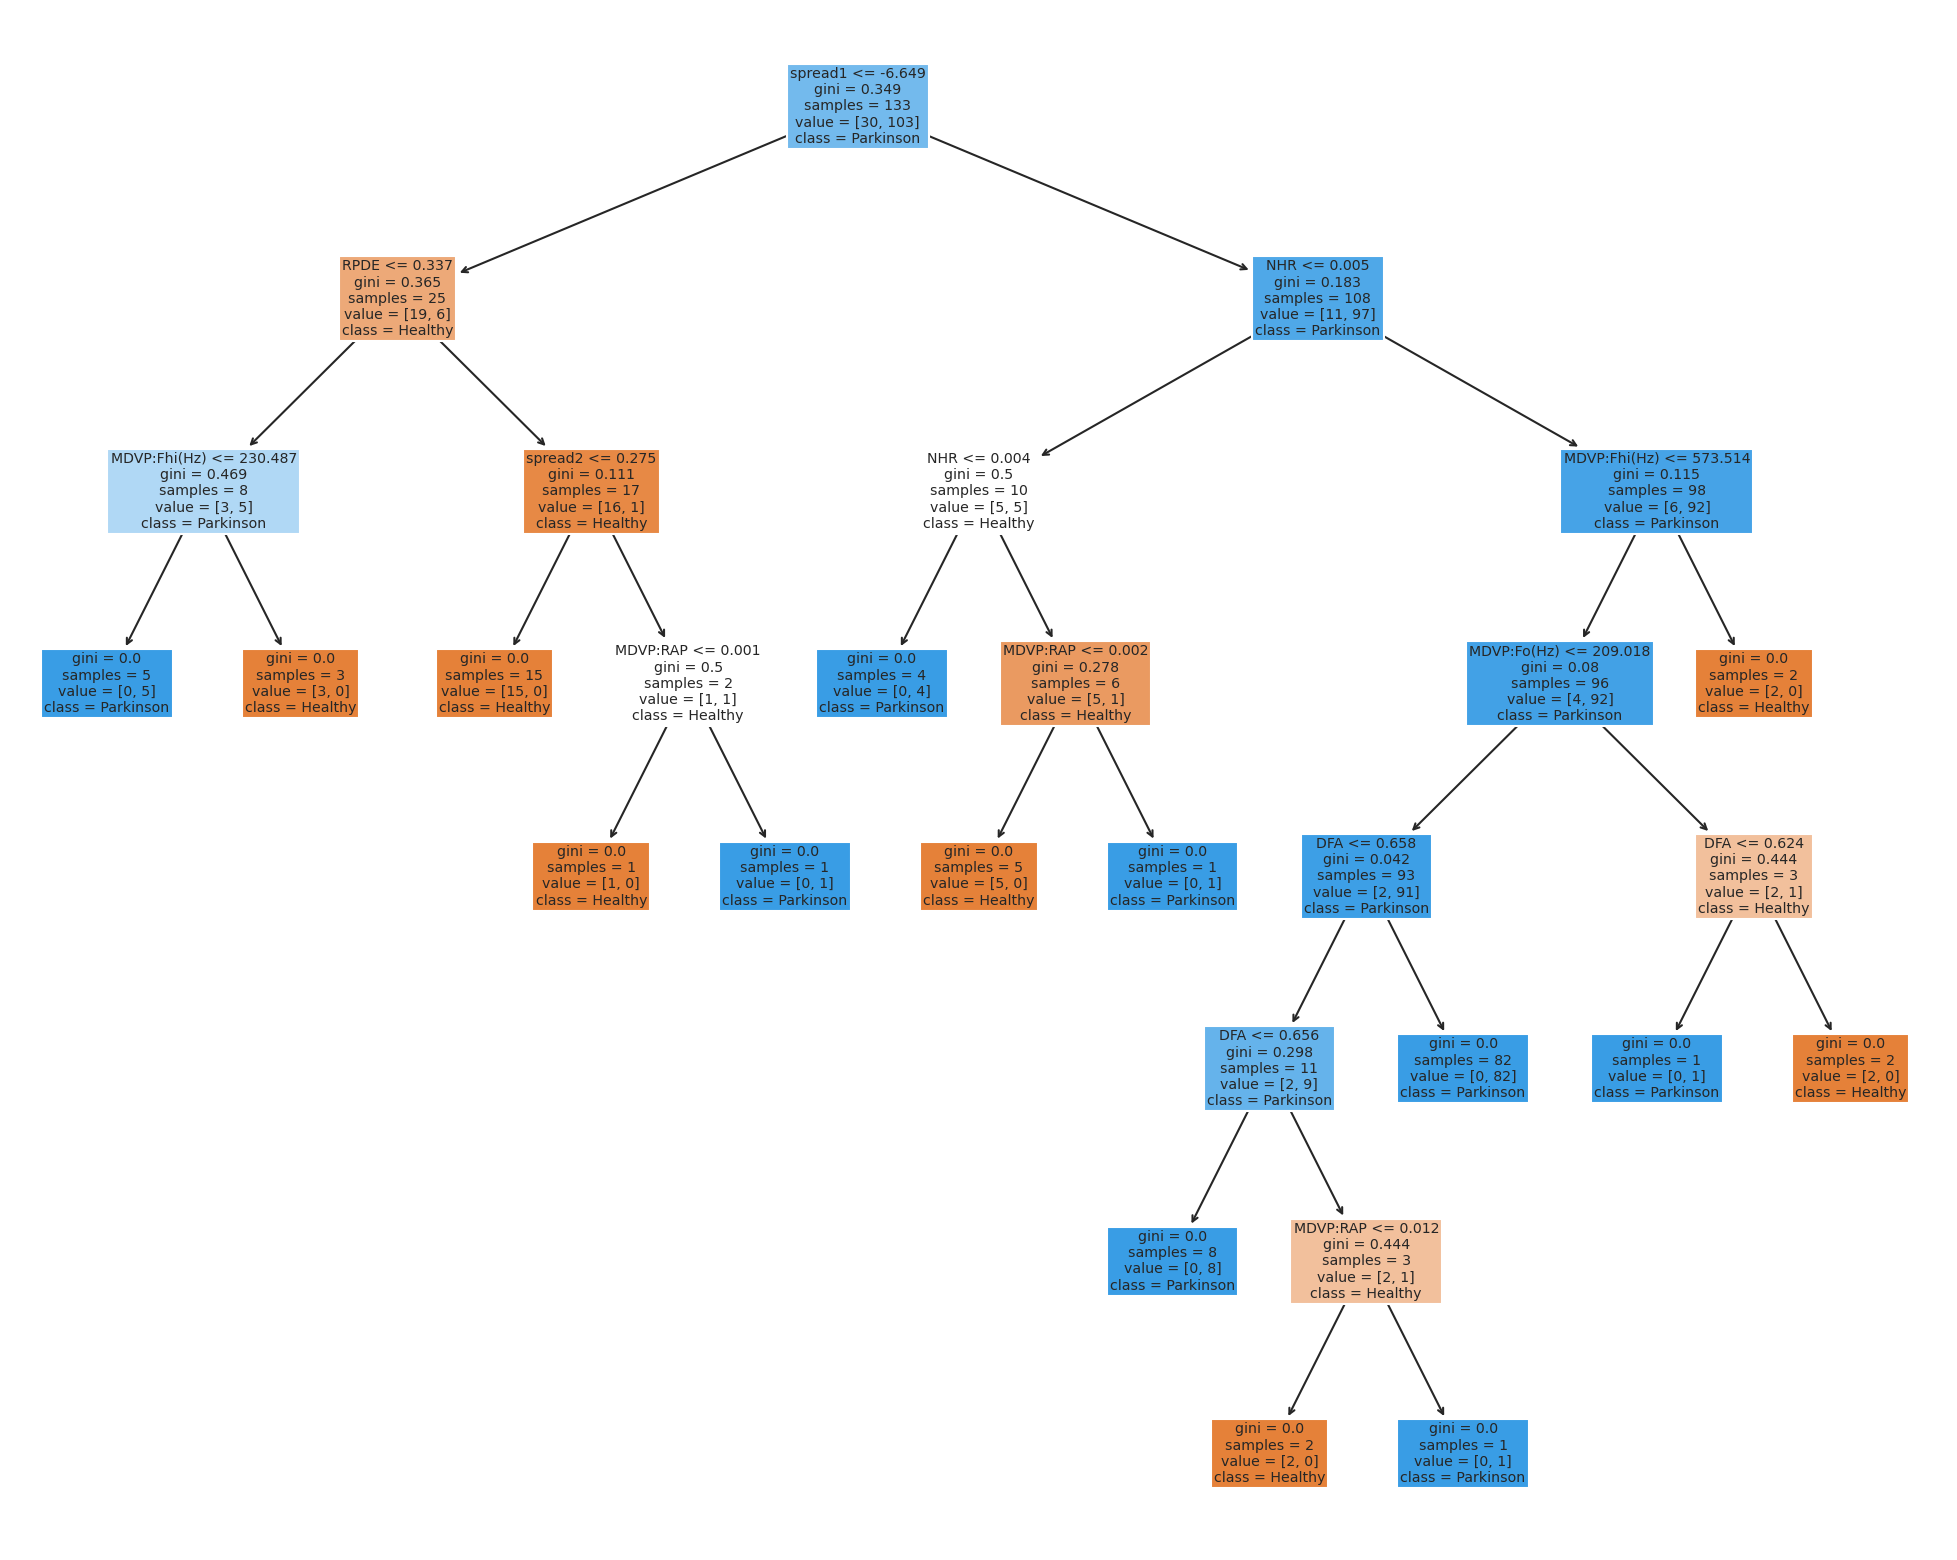

In [ ]:
plt.figure(figsize=(25,20))
plot_tree(TD_clf_234733T, feature_names = cause_cols, class_names= ["Healthy", "Parkinson"], filled=True)
plt.show()

####Evaluation of the model

In [ ]:
print(cause_cols)
print(len(cause_cols), 'features in total')
print(TD_clf_234733T.feature_importances_)


['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']
22 features in total
[0.05206702 0.15815033 0.         0.         0.         0.08608414
 0.         0.         0.         0.         0.         0.
 0.         0.         0.14693028 0.         0.07505778 0.08423287
 0.37848843 0.01898915 0.         0.        ]


[Text(0, 0.5, 'Relative Importance')]

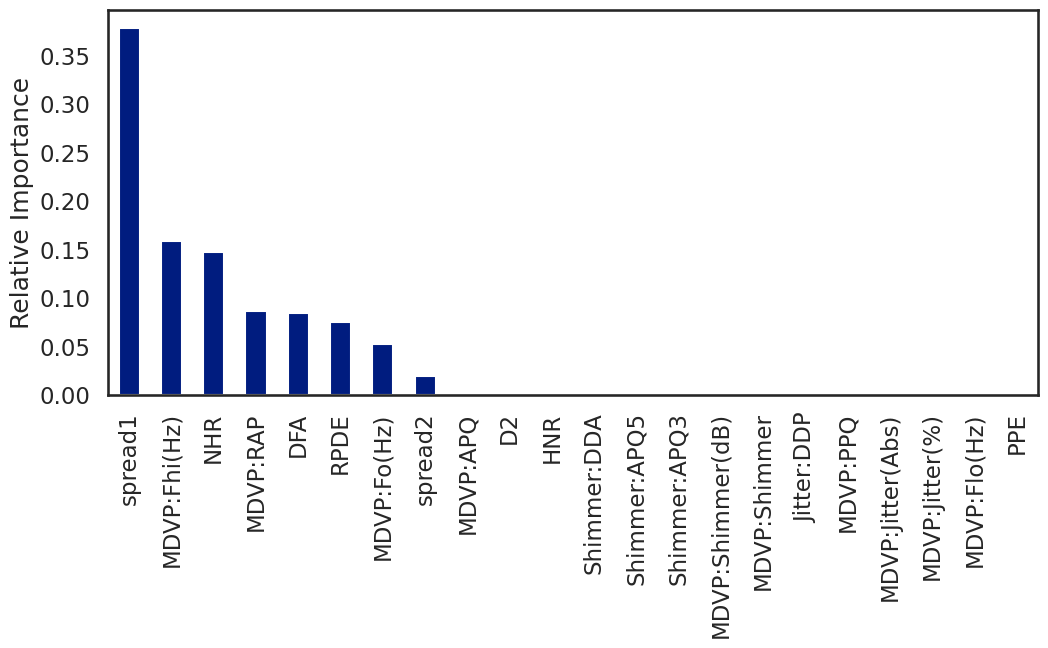

In [ ]:
imp = pd.Series(TD_clf_234733T.feature_importances_, index= cause_cols).sort_values(ascending=False)
fig = plt.figure(figsize=(12,5))
ax = imp.plot(kind='bar')
ax.set(ylabel='Relative Importance')

In [ ]:

# We define a function to return various error metrics
def measure_error(y_true, y_pred, label):
    return pd.Series({'accuracy':accuracy_score(y_true, y_pred),
    'precision': precision_score(y_true, y_pred),
    'recall': recall_score(y_true, y_pred),
    'f1': f1_score(y_true, y_pred)},
    name=label)
# The error on the training and test data sets
# Get the performance of the trained model on the training and test sets
y_train_pred = TD_clf_234733T.predict(x_train)
y_test_pred = TD_clf_234733T.predict(x_test)

train_test_full_error = pd.concat([measure_error(y_train, y_train_pred, 'train'),
measure_error(y_test, y_test_pred, 'test')],
axis=1)
train_test_full_error

,train,test
accuracy,1.0,0.789474
precision,1.0,0.853659
recall,1.0,0.853659
f1,1.0,0.853659


In [ ]:

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.62      0.62      0.62        16
           1       0.85      0.85      0.85        41

    accuracy                           0.79        57
   macro avg       0.74      0.74      0.74        57
weighted avg       0.79      0.79      0.79        57



In [ ]:
mat_234733T = confusion_matrix(y_test, y_test_pred)
mat_234733T

array([[10,  6],
       [ 6, 35]])

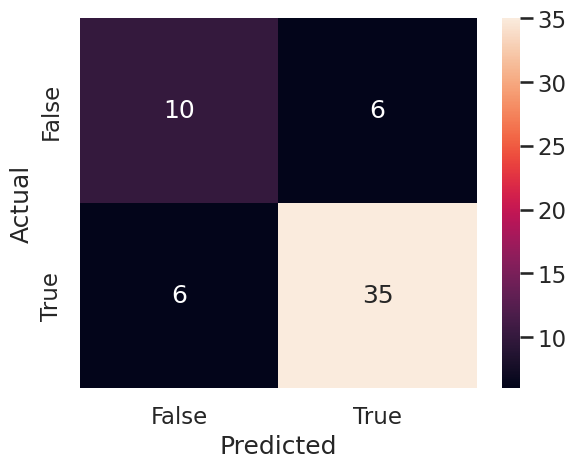

In [ ]:
sns.set_context('talk')
ax = sns.heatmap(mat_234733T, annot=True, fmt='d')
labels = ['False', 'True']
ax.set_xticklabels(labels);
ax.set_yticklabels(labels);
ax.set_ylabel('Actual');
ax.set_xlabel('Predicted');

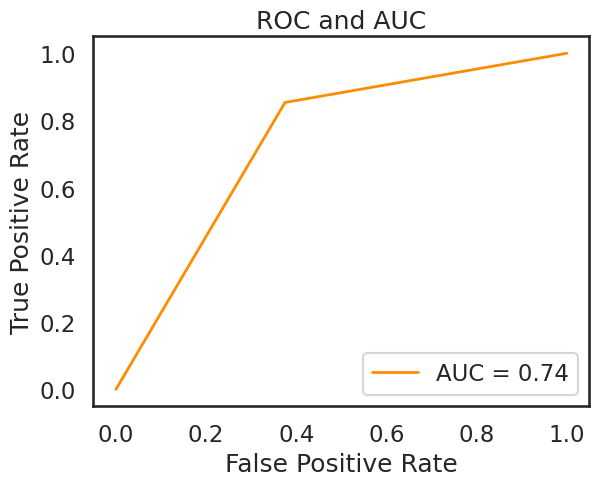

In [ ]:
y_probs = TD_clf_234733T.predict_proba(x_test)
y_probs = y_probs[:, 1]
fpr, tpr, threshold = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr,tpr, color="darkorange", lw=2, label="AUC = %0.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC and AUC")
plt.legend(loc="lower right")
plt.show()


### Using GridSearch to find optimal hyperparameters Regularization

In [ ]:
#define search range
param_grid = {'max_depth': range(1, 10),
              'max_features': [1,2,3,4]}

gr_clf_234733T = GridSearchCV(tree.DecisionTreeClassifier(random_state=42),
                         param_grid=param_grid,
                         scoring='accuracy', n_jobs=-1)

gr_clf_234733T = gr_clf_234733T.fit(x_train, y_train)

print('Best max_depth is:', gr_clf_234733T.best_estimator_.tree_.max_depth)
print('Best max_features is:', gr_clf_234733T.best_estimator_.tree_.node_count)

acc = gr_clf_234733T.score(x_test, y_test)
print("Accuracy=", acc)

Best max_depth is: 7
Best max_features is: 29
Accuracy= 0.8596491228070176


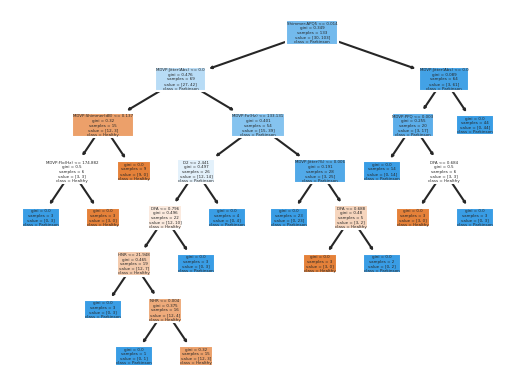

In [ ]:
plot_tree(gr_clf_234733T.best_estimator_, filled=True, feature_names = cause_cols, class_names= ["Healthy", "Parkinson"])
plt.show()

In [ ]:
#Check feature improtance
gr_clf_234733T.best_estimator_.feature_importances_

array([0.0812757 , 0.        , 0.07200087, 0.07097228, 0.16852159,
       0.        , 0.05040061, 0.        , 0.        , 0.04320052,
       0.        , 0.18907068, 0.        , 0.        , 0.02880035,
       0.06821135, 0.        , 0.17920981, 0.        , 0.        ,
       0.04833625, 0.        ])

In [ ]:
y_train_pred_2 = gr_clf_234733T.best_estimator_.predict(x_train)
y_test_pred_2 = gr_clf_234733T.best_estimator_.predict(x_test)
train_test_full_error = pd.concat([measure_error(y_train, y_train_pred_2, 'train'),
measure_error(y_test, y_test_pred_2, 'test')],
axis=1)
train_test_full_error

,train,test
accuracy,0.977444,0.859649
precision,1.000000,0.923077
recall,0.970874,0.878049
f1,0.985222,0.900000


In [ ]:
y_train_pred_prob = gr_clf_234733T.predict_proba(x_train)
y_test_pred_prob = gr_clf_234733T.predict_proba(x_test)

In [ ]:
y_train_pred_prob

array([[0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [1. , 0. ],
       [0. , 1. ],
       [0. , 1. ],
       [0.8, 0.2],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0.8, 0.2],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [1. , 0. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0.8, 0.2],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0.8, 0.2],
       [0. , 1. ],
       [0. , 1. ],
       [0.8, 0.2],
       [0. , 1. ],
       [1. , 0. ],
       [0. , 1. ],
       [1. , 0. ],
       [1. , 0. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0.8, 0.2],
       [0. , 1. ],
       [1. ,

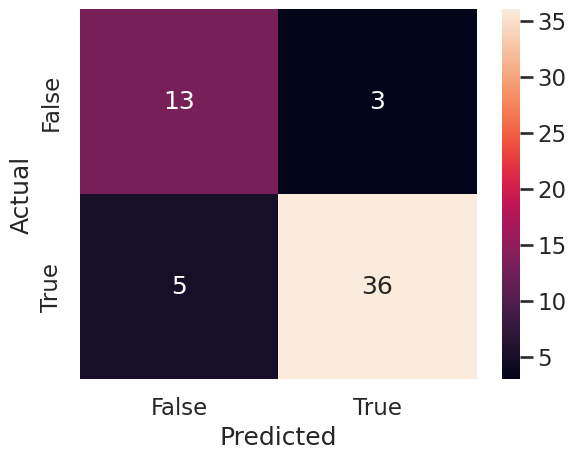

In [ ]:
mat2 = confusion_matrix(y_test, y_test_pred_2)

sns.set_context('talk')
ax = sns.heatmap(mat2, annot=True, fmt='d')
labels = ['False', 'True']
ax.set_xticklabels(labels);
ax.set_yticklabels(labels);
ax.set_ylabel('Actual');
ax.set_xlabel('Predicted');

In [ ]:
print(classification_report(y_test, y_test_pred_2))

              precision    recall  f1-score   support

           0       0.72      0.81      0.76        16
           1       0.92      0.88      0.90        41

    accuracy                           0.86        57
   macro avg       0.82      0.85      0.83        57
weighted avg       0.87      0.86      0.86        57



In [ ]:
y_train_scores = y_train_pred_prob[:, 1]
# we use the positive class (churned) probability as the decision score
# Now, let's take a look at the precision/recall curve
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_scores)
precisions, recalls, thresholds

(array([0.77443609, 0.89565217, 1.        , 1.        ]),
 array([1.        , 1.        , 0.97087379, 0.        ]),
 array([0. , 0.2, 1. ]))

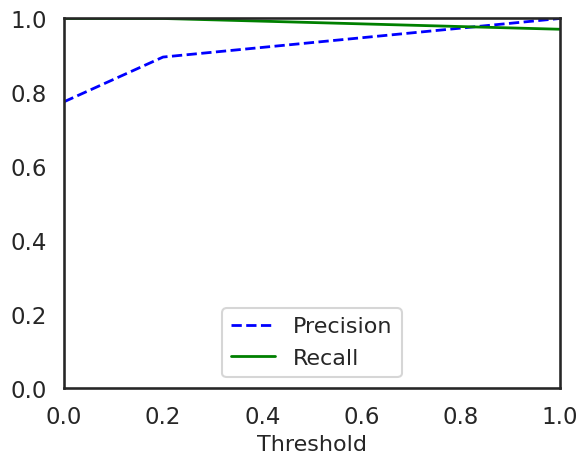

<Figure size 800x400 with 0 Axes>

In [ ]:
def plot_precision_recall_curve(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.xlabel("Threshold", fontsize=16)
    plt.legend(loc="lower center", fontsize=16)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.figure(figsize=(8, 4))
plot_precision_recall_curve(precisions, recalls, thresholds)
plt.show()

In [ ]:
gr_clf_234733T.best_params_

{'max_depth': 7, 'max_features': 2}

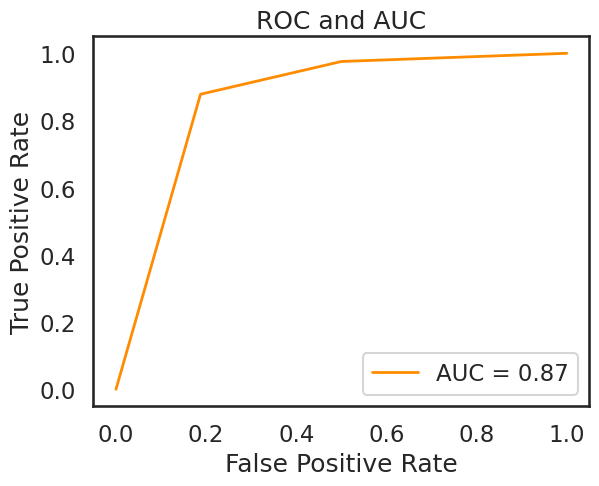

In [ ]:
y_probs = gr_clf_234733T.predict_proba(x_test)
y_probs = y_probs[:, 1]
fpr, tpr, threshold = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr,tpr, color="darkorange", lw=2, label="AUC = %0.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC and AUC")
plt.legend(loc="lower right")
plt.show()


#### Second Gridsearch

In [ ]:
wpa = TD_clf_234733T.get_params()
wpa

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 42,
 'splitter': 'best'}

In [ ]:
#define search range
param_grid = {   'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],}

gr2_clf_234733T = GridSearchCV(tree.DecisionTreeClassifier(random_state=42),
                         param_grid=param_grid,
                         scoring='accuracy', n_jobs=-1)

gr2_clf_234733T = gr2_clf_234733T.fit(x_train, y_train)

print('Best max_depth is:', gr2_clf_234733T.best_estimator_.tree_.max_depth)
print('Best max_features is:', gr2_clf_234733T.best_estimator_.tree_.node_count)

acc = gr2_clf_234733T.score(x_test, y_test)
print("Accuracy=", acc)

Best max_depth is: 5
Best max_features is: 19
Accuracy= 0.8947368421052632


In [ ]:
gr2_clf_234733T.best_params_

{'criterion': 'entropy',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5}

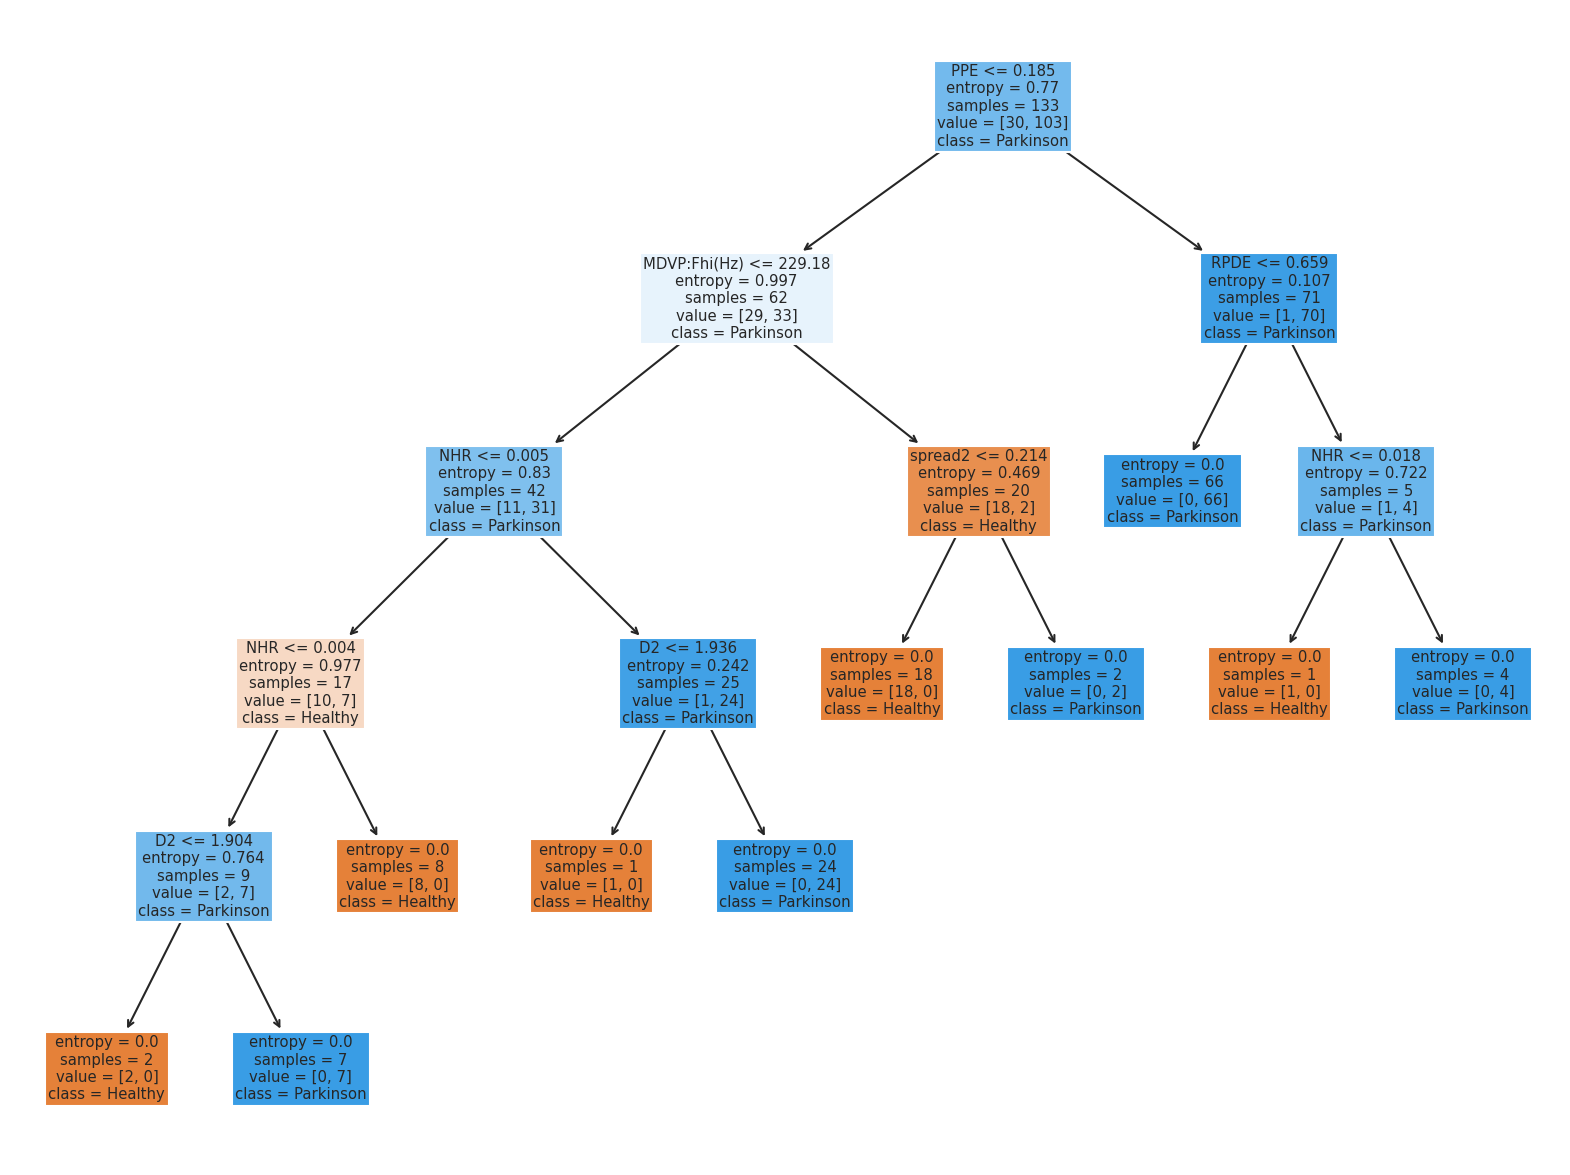

In [ ]:
plt.figure(figsize=(20,15))
plot_tree(gr2_clf_234733T.best_estimator_, filled=True, feature_names = cause_cols, class_names= ["Healthy", "Parkinson"])
plt.show()

In [ ]:
gr2_clf_234733T.best_estimator_.feature_importances_

array([0.        , 0.17171948, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.24911087,
       0.        , 0.03878112, 0.        , 0.        , 0.09156825,
       0.12627502, 0.32254527])

In [ ]:
y_train_p = gr2_clf_234733T.best_estimator_.predict(x_train)
y_test_p = gr2_clf_234733T.best_estimator_.predict(x_test)
train_test_full_error = pd.concat([measure_error(y_train, y_train_p, 'train'),
measure_error(y_test, y_test_p, 'test')],
axis=1)
train_test_full_error

,train,test
accuracy,1.0,0.894737
precision,1.0,0.888889
recall,1.0,0.975610
f1,1.0,0.930233


In [ ]:
y_train_pred_prob = gr2_clf_234733T.predict_proba(x_train)
y_test_pred_prob = gr2_clf_234733T.predict_proba(x_test)

In [ ]:
y_train_pred_prob

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.

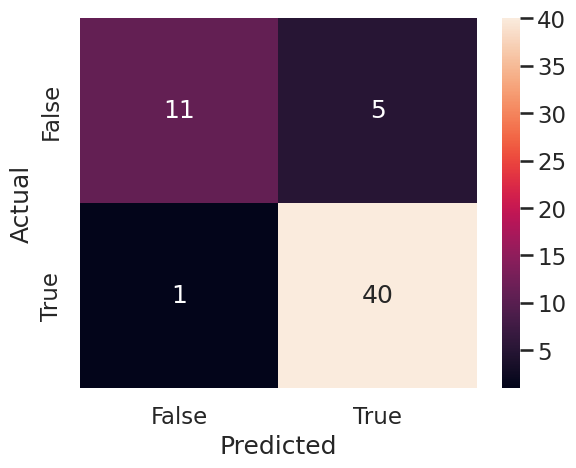

In [ ]:
ma = confusion_matrix(y_test, y_test_p)

sns.set_context('talk')
ax = sns.heatmap(ma, annot=True, fmt='d')
labels = ['False', 'True']
ax.set_xticklabels(labels);
ax.set_yticklabels(labels);
ax.set_ylabel('Actual');
ax.set_xlabel('Predicted');

In [ ]:
print(classification_report(y_test, y_test_p))

              precision    recall  f1-score   support

           0       0.92      0.69      0.79        16
           1       0.89      0.98      0.93        41

    accuracy                           0.89        57
   macro avg       0.90      0.83      0.86        57
weighted avg       0.90      0.89      0.89        57



In [ ]:
y_train_scores = y_train_pred_prob[:, 1]
# we use the positive class (churned) probability as the decision score
# Now, let's take a look at the precision/recall curve
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_scores)
precisions, recalls, thresholds

(array([0.77443609, 1.        , 1.        ]),
 array([1., 1., 0.]),
 array([0., 1.]))

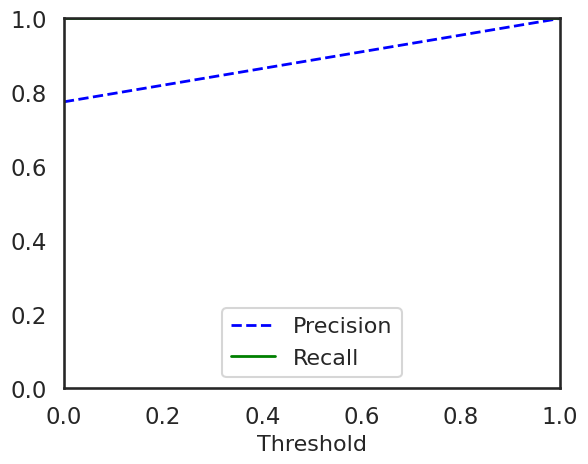

<Figure size 800x400 with 0 Axes>

In [ ]:
def plot_precision_recall_curve(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.xlabel("Threshold", fontsize=16)
    plt.legend(loc="lower center", fontsize=16)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.figure(figsize=(8, 4))
plot_precision_recall_curve(precisions, recalls, thresholds)
plt.show()

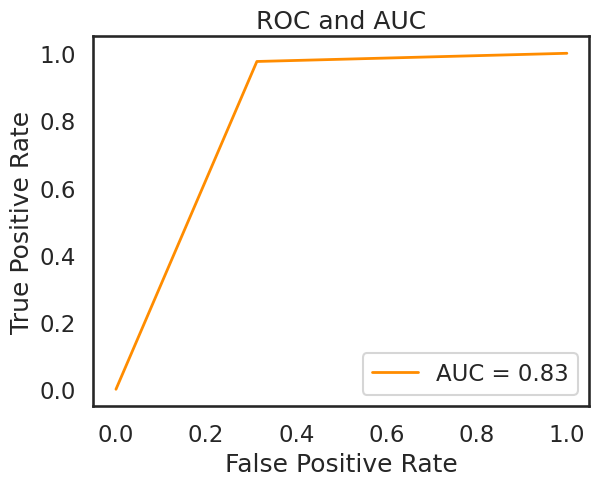

In [ ]:
y_probs = gr2_clf_234733T.predict_proba(x_test)
y_probs = y_probs[:, 1]
fpr, tpr, threshold = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr,tpr, color="darkorange", lw=2, label="AUC = %0.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC and AUC")
plt.legend(loc="lower right")
plt.show()

##Ensemble Method

#### RandomForest

I chose the Random Forest method because it balances higher bias with lower variance, often resulting in a better overall model. The Out-of-Bag  method helped us determine the optimal number of trees n_estimators, finding that adding more than 11 trees didn't significantly improve accuracy. We used GridSearchCV to optimize hyperparameters like the number of trees, tree depth, and criteria for splitting. This tuning have the same performance and with same accuracy of 91% while regularization was not need as the deafault have use the best parameters

In [ ]:
rfclf_234733T = RandomForestClassifier(random_state=42)
rfclf_234733T.fit(x_train,y_train)
acc = rfclf_234733T.score(x_test,y_test)
print('Accuracy:', acc)
print('Number of trees:', rfclf_234733T.n_estimators)

Accuracy: 0.9122807017543859
Number of trees: 100


In [ ]:
acc_list = []

# Iterate through a range of numbers of trees
for n_trees in range(2,20):
    # Use this to set the number of trees
    rfclf_234733T.set_params(n_estimators=n_trees)
    rfclf_234733T.fit(x_train, y_train)

    acc = rfclf_234733T.score(x_test,y_test)
    acc_list.append(pd.Series({'n_trees': n_trees, 'acc': acc}))

pd.concat(acc_list, axis=1).T.set_index('n_trees')

,acc
n_trees,
2.0,0.824561
3.0,0.859649
4.0,0.842105
5.0,0.859649
6.0,0.842105
7.0,0.842105
8.0,0.842105
9.0,0.859649
10.0,0.859649


The total number of trees are 19


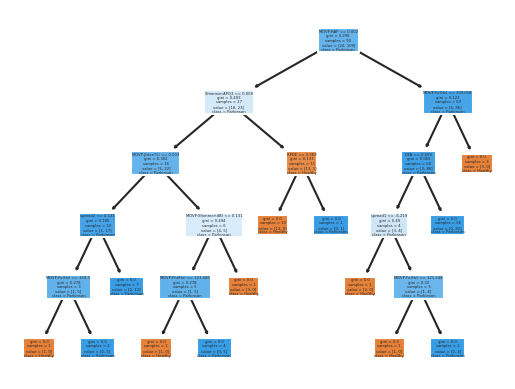

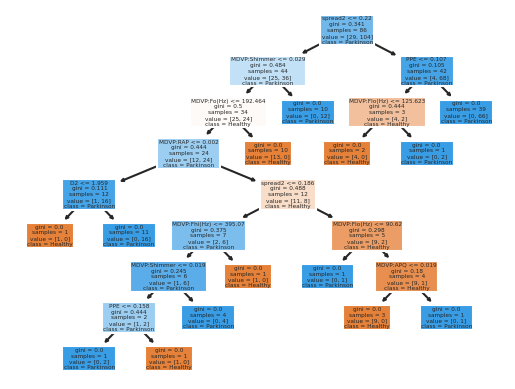

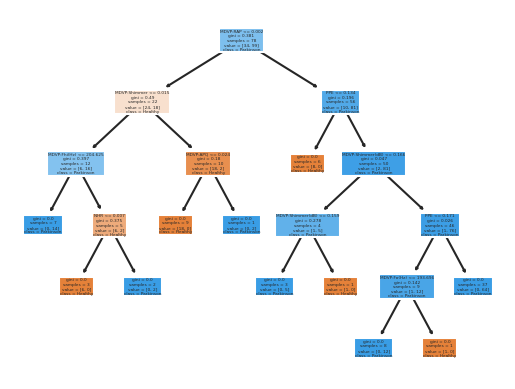

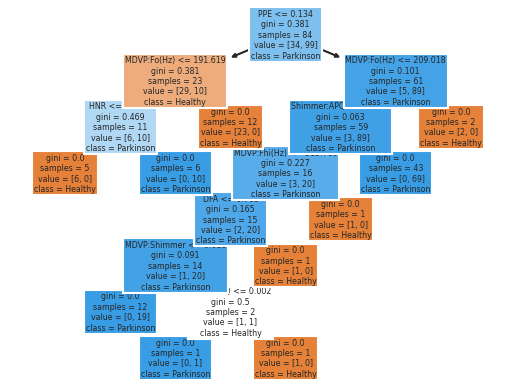

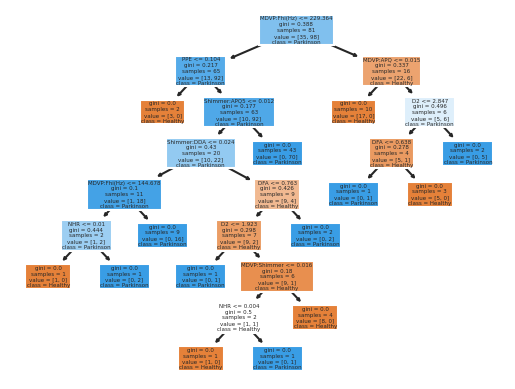

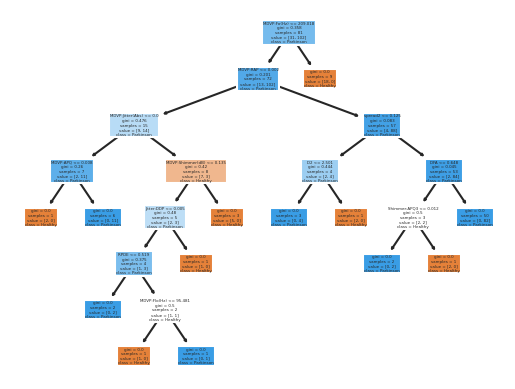

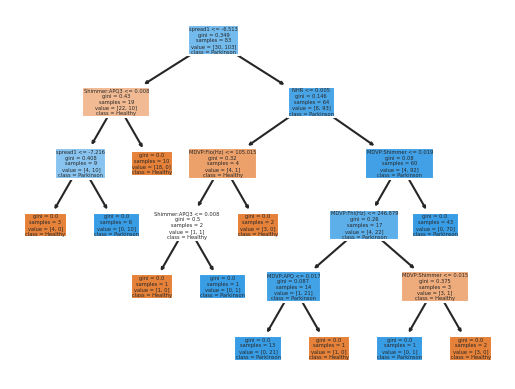

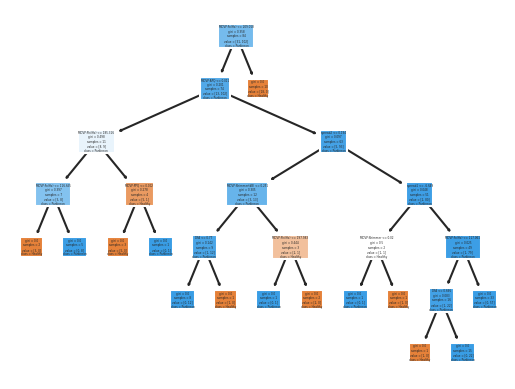

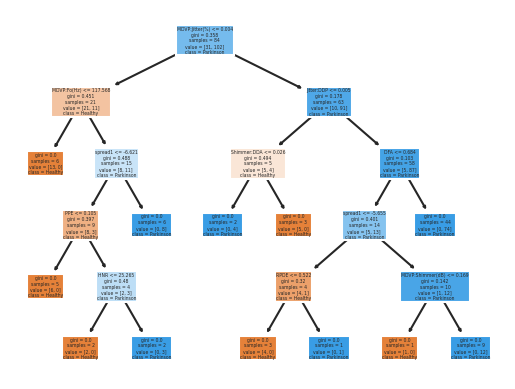

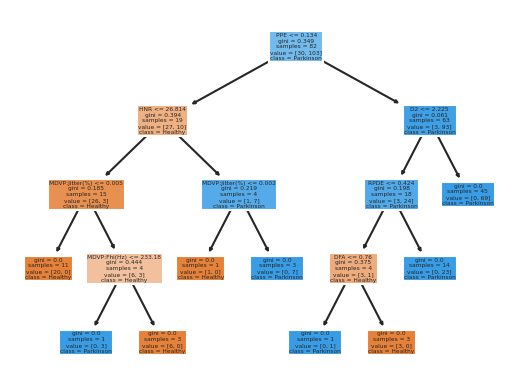

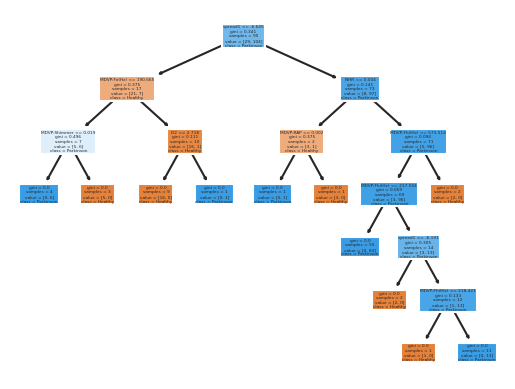

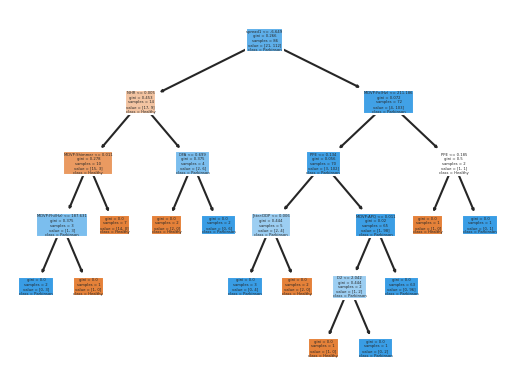

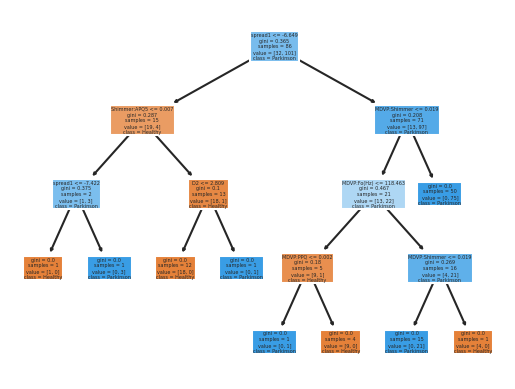

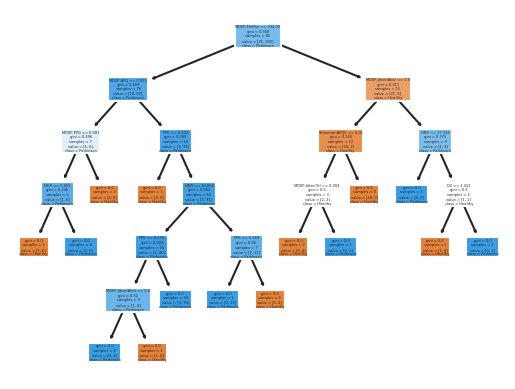

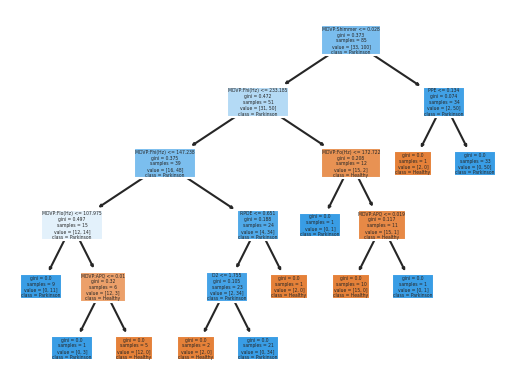

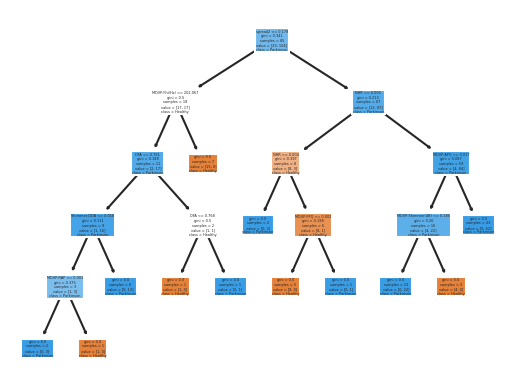

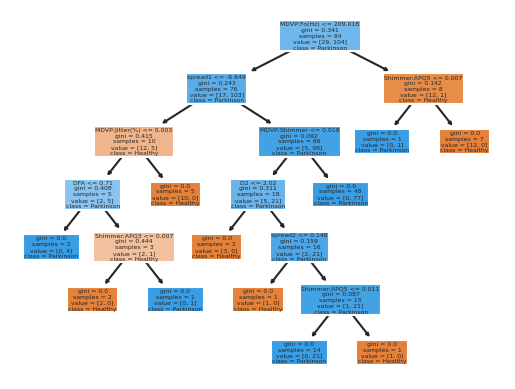

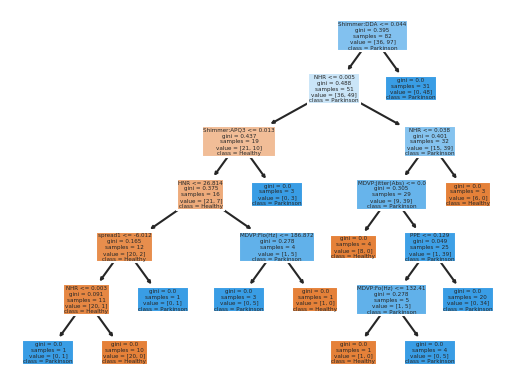

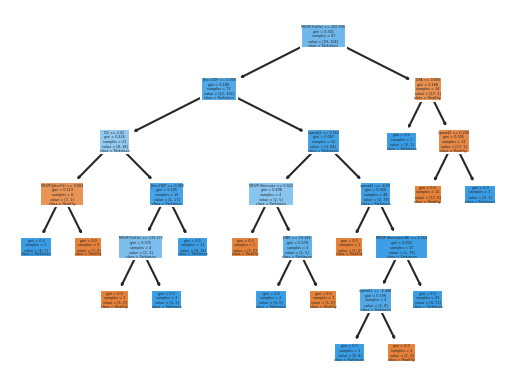

In [ ]:
print('The total number of trees are', len(rfclf_234733T.estimators_))

count = 0
for tree_in_forest in rfclf_234733T.estimators_:
  if count<20:
    plot_tree(tree_in_forest, filled=True, feature_names= cause_cols, class_names=['Healthy', 'Parkinson'])
    plt.show()
    count += 1

#### Evaluation of random forest classifier

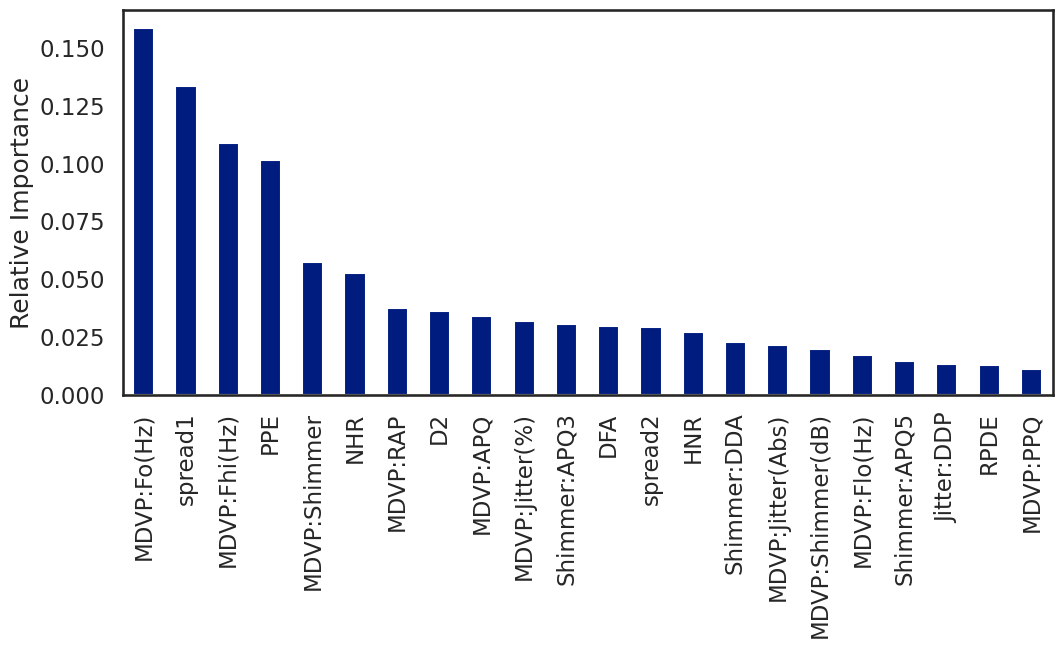

In [ ]:
def measure_error(y_true, y_pred, label):
    return pd.Series({'accuracy':accuracy_score(y_true, y_pred),
                      'precision': precision_score(y_true, y_pred),
                      'recall': recall_score(y_true, y_pred),
                      'f1': f1_score(y_true, y_pred)},
                      name=label)
feature_imp = pd.Series(rfclf_234733T.feature_importances_, index=cause_cols).sort_values(ascending=False)
fig = plt.figure(figsize=(12,5))
ax = feature_imp.plot(kind='bar')
ax.set(ylabel='Relative Importance');

In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      0.69      0.81        16
           1       0.89      1.00      0.94        41

    accuracy                           0.91        57
   macro avg       0.95      0.84      0.88        57
weighted avg       0.92      0.91      0.91        57



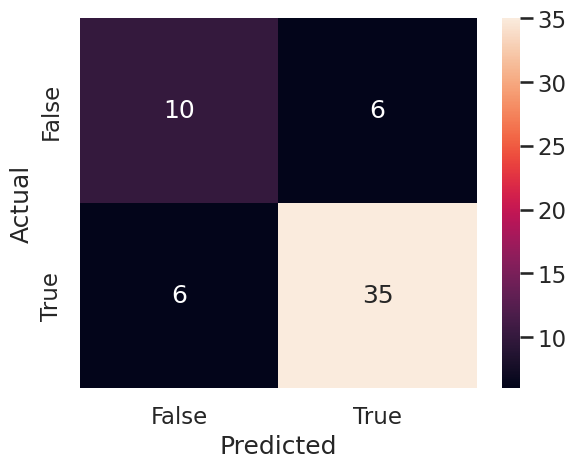

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

sns.set_context('talk')
ax = sns.heatmap(cm, annot=True, fmt='d')
labels = ['False', 'True']
ax.set_xticklabels(labels);
ax.set_yticklabels(labels);
ax.set_ylabel('Actual');
ax.set_xlabel('Predicted');

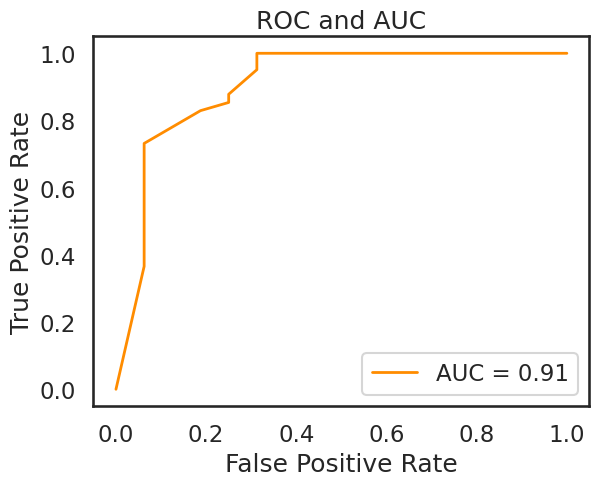

In [ ]:
y_probs = rfclf_234733T.predict_proba(x_test)
y_probs = y_probs[:, 1]
fpr, tpr, threshold = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr,tpr, color="darkorange", lw=2, label="AUC = %0.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC and AUC")
plt.legend(loc="lower right")
plt.show()

## Using of out of bag

In [ ]:
rf_clf_234733T = RandomForestClassifier(oob_score=True,
                                random_state=42,
                                warm_start=True,
                                n_jobs=-1)

oob_list = list()

# Iterate through a range of numbers of trees
for n_trees in [10, 50, 100, 500, 600, 800, 1000, 1100, 1200, 1300, 1400, 1500]:

    rf_clf_234733T.set_params(n_estimators=n_trees)


    rf_clf_234733T.fit(x_train, y_train)


    oob_error = 1 - rf_clf_234733T.oob_score_


    oob_list.append(pd.Series({'n_trees': n_trees, 'oob': oob_error}))

rf_oob_234733T = pd.concat(oob_list, axis=1).T.set_index('n_trees')
rf_oob_234733T

,oob
n_trees,
10.0,0.172932
50.0,0.127820
100.0,0.120301
500.0,0.105263
600.0,0.112782
800.0,0.105263
1000.0,0.105263
1100.0,0.105263
1200.0,0.105263


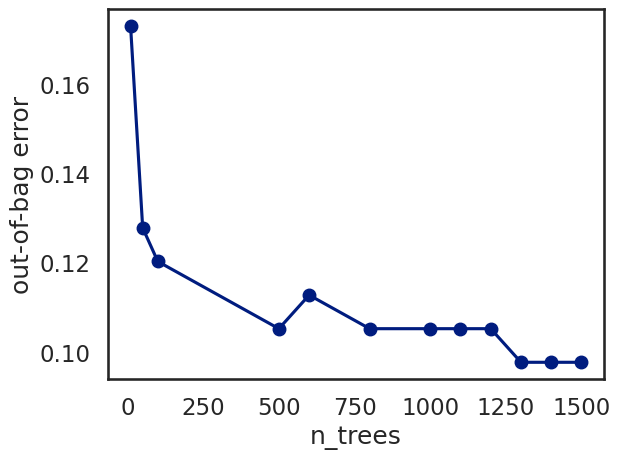

In [ ]:
sns.set_context('talk')
sns.set_palette('dark')
sns.set_style('white')

ax = rf_oob_234733T.plot(legend=False, marker='o')
ax.set(ylabel='out-of-bag error');

In [ ]:
rf_clf_234733T = rf_clf_234733T.set_params(n_estimators=40)

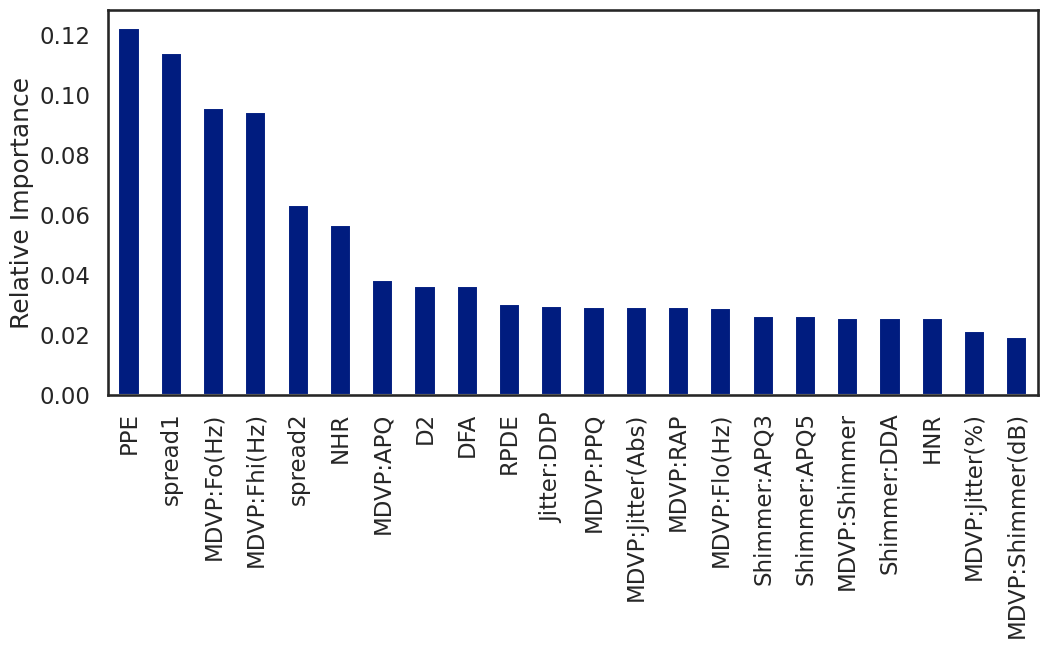

In [ ]:
def measure_error(y_true, y_pred, label):
    return pd.Series({'accuracy':accuracy_score(y_true, y_pred),
                      'precision': precision_score(y_true, y_pred),
                      'recall': recall_score(y_true, y_pred),
                      'f1': f1_score(y_true, y_pred)},
                      name=label)
feature_imp = pd.Series(rf_clf_234733T.feature_importances_, index=cause_cols).sort_values(ascending=False)
fig = plt.figure(figsize=(12,5))
ax = feature_imp.plot(kind='bar')
ax.set(ylabel='Relative Importance');

In [ ]:
y_test_pred3 = cross_val_predict(rf_clf_234733T, x_test, y_test, cv=3, method="predict")
test_error = pd.concat([measure_error(y_test, y_test_pred3, 'test')], axis=1)
test_error

,test
accuracy,0.807018
precision,0.857143
recall,0.878049
f1,0.867470


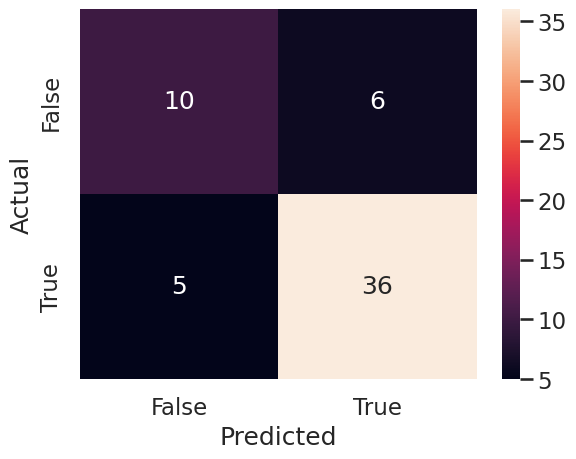

In [ ]:
cm = confusion_matrix(y_test, y_test_pred3)

sns.set_context('talk')
ax = sns.heatmap(cm, annot=True, fmt='d')
labels = ['False', 'True']
ax.set_xticklabels(labels);
ax.set_yticklabels(labels);
ax.set_ylabel('Actual');
ax.set_xlabel('Predicted');

In [ ]:
print(classification_report(y_test, y_test_pred3))

              precision    recall  f1-score   support

           0       0.67      0.62      0.65        16
           1       0.86      0.88      0.87        41

    accuracy                           0.81        57
   macro avg       0.76      0.75      0.76        57
weighted avg       0.80      0.81      0.81        57



## Model Optimization by adjusting the decision threshold

In [ ]:
y_train_pred =  rf_clf_234733T.predict(x_train)
y_train_pred_prob =  rf_clf_234733T.predict_proba(x_train)



In [ ]:
y_train_pred

array([1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1])

In [ ]:
y_train_pred_prob

array([[1.88666667e-01, 8.11333333e-01],
       [1.66000000e-01, 8.34000000e-01],
       [6.33333333e-02, 9.36666667e-01],
       [6.66666667e-04, 9.99333333e-01],
       [6.66666667e-04, 9.99333333e-01],
       [7.29333333e-01, 2.70666667e-01],
       [8.20000000e-02, 9.18000000e-01],
       [1.33333333e-03, 9.98666667e-01],
       [8.26000000e-01, 1.74000000e-01],
       [2.53333333e-02, 9.74666667e-01],
       [1.34666667e-01, 8.65333333e-01],
       [2.26666667e-02, 9.77333333e-01],
       [1.16666667e-01, 8.83333333e-01],
       [1.20000000e-02, 9.88000000e-01],
       [4.86666667e-02, 9.51333333e-01],
       [1.34666667e-01, 8.65333333e-01],
       [7.26666667e-02, 9.27333333e-01],
       [8.48000000e-01, 1.52000000e-01],
       [1.45333333e-01, 8.54666667e-01],
       [5.46666667e-02, 9.45333333e-01],
       [2.00000000e-02, 9.80000000e-01],
       [2.43333333e-01, 7.56666667e-01],
       [1.08666667e-01, 8.91333333e-01],
       [1.34666667e-01, 8.65333333e-01],
       [2.000000

In [ ]:
# y_train = y_train.replace(True, 1).replace(False, 0).astype(np.int64)
# y_train_scores = y_train_pred_prob[:, 1]
# train_predict = pd.DataFrame({'actual': y_train.values,
#                               'predict': y_train_scores})
# # train_predict
# color =np.array([0.5, 0.6, 0.7]).reshape(1,-1)

# train_predict.plot.scatter(x='predict', y='actual', s=list(range(3500)), alpha=0.05, figsize=(10,6), c= color)

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_scores)

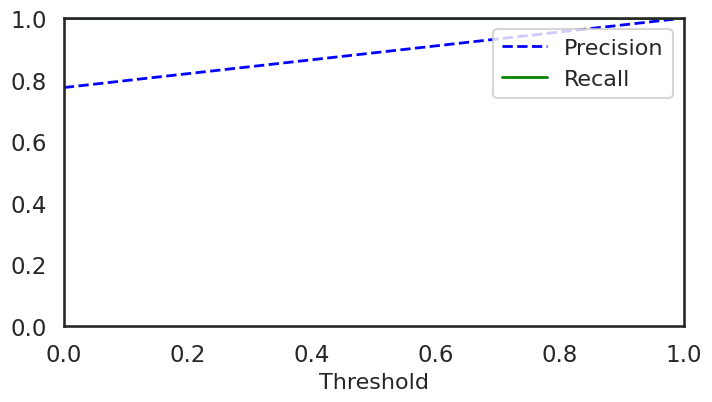

In [ ]:
def plot_precision_recall_curve(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.xlabel("Threshold", fontsize=16)
    plt.legend(loc="upper right", fontsize=16)
    plt.xlim([0, 1])
    plt.ylim([0, 1])

plt.figure(figsize=(8, 4))
plot_precision_recall_curve(precisions, recalls, thresholds)
plt.show()

In [ ]:
y_train_pred = (y_train_scores > 0.7)

In [ ]:
train_error = pd.concat([measure_error(y_train, y_train_pred, 'train')], axis=1)  #combined in rows
train_error

,train
accuracy,1.0
precision,1.0
recall,1.0
f1,1.0


In [ ]:
print(confusion_matrix(y_train, y_train_pred))

[[ 30   0]
 [  0 103]]


In [ ]:
y_test_pred_prob = rf_clf_234733T.predict_proba(x_test)
y_test_pred_prob

array([[7.33333333e-02, 9.26666667e-01],
       [3.62000000e-01, 6.38000000e-01],
       [2.30000000e-01, 7.70000000e-01],
       [1.20666667e-01, 8.79333333e-01],
       [1.90000000e-01, 8.10000000e-01],
       [6.66666667e-02, 9.33333333e-01],
       [2.80000000e-02, 9.72000000e-01],
       [9.33333333e-03, 9.90666667e-01],
       [3.07333333e-01, 6.92666667e-01],
       [4.09333333e-01, 5.90666667e-01],
       [2.54000000e-01, 7.46000000e-01],
       [2.66666667e-03, 9.97333333e-01],
       [8.00000000e-03, 9.92000000e-01],
       [9.03333333e-01, 9.66666667e-02],
       [4.00000000e-03, 9.96000000e-01],
       [7.73333333e-02, 9.22666667e-01],
       [1.30000000e-01, 8.70000000e-01],
       [3.20000000e-02, 9.68000000e-01],
       [8.24000000e-01, 1.76000000e-01],
       [8.79333333e-01, 1.20666667e-01],
       [6.46000000e-01, 3.54000000e-01],
       [9.80000000e-02, 9.02000000e-01],
       [1.33333333e-03, 9.98666667e-01],
       [2.80000000e-02, 9.72000000e-01],
       [2.873333

In [ ]:
y_test_scores = y_test_pred_prob[:, 1]
y_test_scores

array([0.92666667, 0.638     , 0.77      , 0.87933333, 0.81      ,
       0.93333333, 0.972     , 0.99066667, 0.69266667, 0.59066667,
       0.746     , 0.99733333, 0.992     , 0.09666667, 0.996     ,
       0.92266667, 0.87      , 0.968     , 0.176     , 0.12066667,
       0.354     , 0.902     , 0.99866667, 0.972     , 0.71266667,
       0.84733333, 0.952     , 0.99866667, 0.59333333, 0.99866667,
       0.30666667, 0.998     , 0.69466667, 0.99733333, 0.66266667,
       0.848     , 0.93533333, 0.79933333, 1.        , 0.83133333,
       0.98666667, 0.17266667, 0.14933333, 0.97866667, 0.892     ,
       0.35466667, 0.84733333, 0.972     , 0.10733333, 0.26133333,
       0.972     , 0.906     , 0.17      , 0.86733333, 0.92066667,
       0.91066667, 0.99933333])

In [ ]:
y_test_pred = (y_test_scores > 0.7)

In [ ]:
test_error = pd.concat([measure_error(y_test, y_test_pred, 'test')], axis=1)
test_error

,test
accuracy,0.912281
precision,0.950000
recall,0.926829
f1,0.938272


In [ ]:
print(confusion_matrix(y_test, y_test_pred))

[[14  2]
 [ 3 38]]


#### Optimize random forest classifier using grid search

In [ ]:
par_used= rfclf_234733T.get_params()
par_used

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 19,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
param_grid = {'n_estimators': [5,10,20,30,40,50,100,200,300,400,500],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10], }


gr_rf_clf_234733T = GridSearchCV(RandomForestClassifier(random_state=42, warm_start=True, n_jobs=-1),
                         param_grid=param_grid,
                         scoring='accuracy',
                         n_jobs=-1)

gr_rf_clf_234733T = gr_rf_clf_234733T.fit(x_train, y_train)

In [ ]:
gr_rf_clf_234733T.best_params_

{'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 40}

In [ ]:
y_train_pred_gr = gr_rf_clf_234733T.predict(x_train)
y_test_pred_gr = gr_rf_clf_234733T.predict(x_test)

train_test_error = pd.concat([measure_error(y_train, y_train_pred_gr, 'train'),
                              measure_error(y_test, y_test_pred_gr, 'test')],
                              axis=1)

train_test_error

,train,test
accuracy,1.0,0.912281
precision,1.0,0.891304
recall,1.0,1.000000
f1,1.0,0.942529


In [ ]:
print(classification_report(y_test, y_test_pred_gr))

              precision    recall  f1-score   support

           0       1.00      0.69      0.81        16
           1       0.89      1.00      0.94        41

    accuracy                           0.91        57
   macro avg       0.95      0.84      0.88        57
weighted avg       0.92      0.91      0.91        57



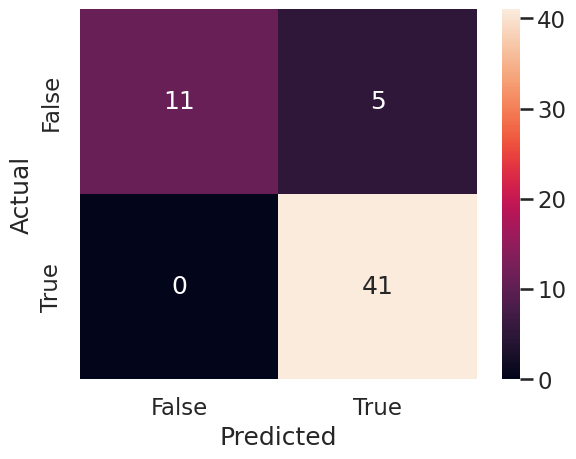

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

sns.set_context('talk')
ax = sns.heatmap(cm, annot=True, fmt='d')
labels = ['False', 'True']
ax.set_xticklabels(labels);
ax.set_yticklabels(labels);
ax.set_ylabel('Actual');
ax.set_xlabel('Predicted');

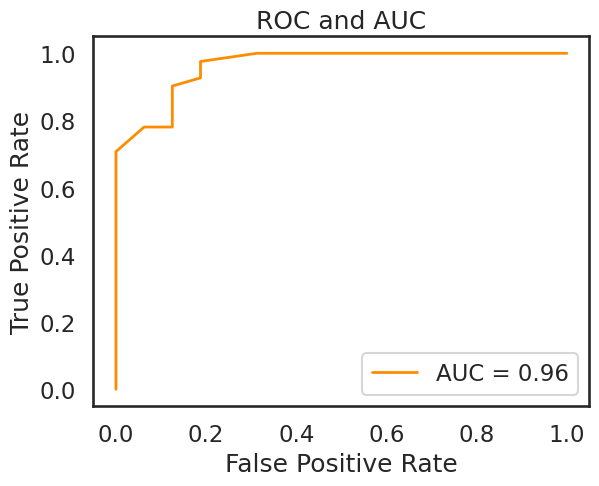

In [ ]:
y_probs = gr_rf_clf_234733T.predict_proba(x_test)
y_probs = y_probs[:, 1]
fpr, tpr, threshold = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr,tpr, color="darkorange", lw=2, label="AUC = %0.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC and AUC")
plt.legend(loc="lower right")
plt.show()

## comparison with decision tree and  random forest

In [ ]:
y_pred_tree = TD_clf_234733T.predict(x_test)
y_pred_forest = rfclf_234733T.predict(x_test)

# Evaluate the models
com = {
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_tree), accuracy_score(y_test, y_pred_forest)],
    "Precision": [precision_score(y_test, y_pred_tree), precision_score(y_test, y_pred_forest)],
    "Recall": [recall_score(y_test, y_pred_tree), recall_score(y_test, y_pred_forest)],
    "F1-Score": [f1_score(y_test, y_pred_tree), f1_score(y_test, y_pred_forest)]
}

comp = pd.DataFrame(com)
comp

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.789474,0.853659,0.853659,0.853659
1,Random Forest,0.912281,0.891304,1.000000,0.942529


The Random Forest outperforms the Decision Tree in predicting whether a patient has Parkinson's disease. It has higher accuracy, meaning it's more reliable for making correct predictions.

Random Forest also has higher precision, which means it's better at avoiding false positives—incorrectly diagnosing healthy people as having Parkinson's. Additionally, it has higher recall, so it's more effective at identifying all patients who actually have the disease, reducing the chances of missing cases.

The F1-Score of Random Forest is higher, showing it's more balanced, dependable, and consistent compared to the Decision Tree.

Random Foresthave  A higher AUC score than decision tree means it's better at correctly identifying true positives while minimizing false positives and negatives.

Finally, Random Forest naturally manages regularization by averaging multiple decision trees, which reduces model variance and decreases the risk of overfitting—a common issue with Decision Trees. This makes Random Forest a more robust and reliable choice overall.